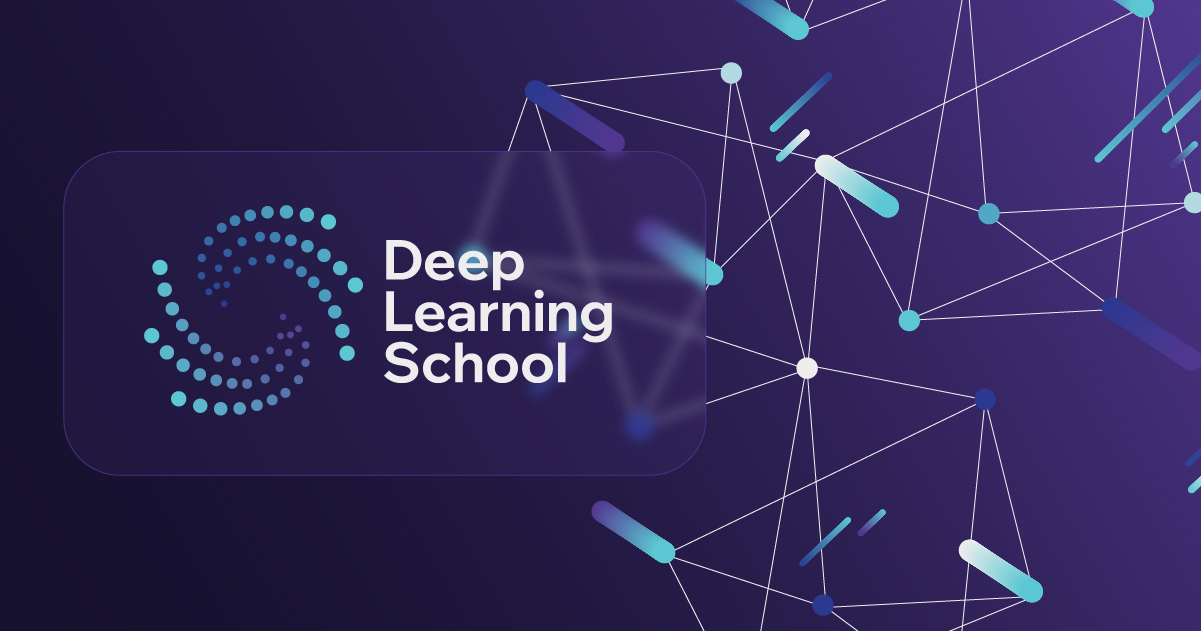

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание по теме "Механизм внимания.</b></h1>


Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Установка зависимостей

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from typing import Union, List, Optional, Dict, Tuple
import copy
from sklearn.model_selection import train_test_split

from transformers import (
    AutoModel, 
    AutoTokenizer, 
    AutoConfig,
    get_scheduler
)

from datasets import Dataset as HFDataset

from datetime import datetime
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import LabelEncoder

import gdown
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

%matplotlib inline

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
def set_seed(seed=42):
    """
    Фиксация всех источников случайности
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
 
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Детерминированные алгоритмы
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Фиксация хэшей Python
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # Для CUDA
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'   
    
    # Фиксация для DataLoader
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

# Фиксация случайности
SEED = 42
seed_worker = set_seed(SEED)

### Параметры обучения

In [4]:
# Параметры

os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('logs', exist_ok=True)

BASE_FOLDER_PATH = 'models'

MODEL_NAME = 'math_problems_classifier'
LR = 2e-5 # 2e-5 3e-5 5e-5
N_HEADS = 4 # 1 2 3 4


MIN_LENGTH = 10 # 10 20
MAX_LENGTH = 128 # 128 256 512

TEST_SIZE = 0.2 # 0.2
BATCH_SIZE = 16 # 8 16 32
EPOCHS = 5 # 5
DROPOUT = 0.5 # 0.3 0.4 0.5

MODEL_FOLDER_PATH = os.path.join(BASE_FOLDER_PATH, MODEL_NAME)
SCHEDULER_LAMBDA_PARAM = 0.95
PAD_IND = 0

os.makedirs(MODEL_FOLDER_PATH, exist_ok=True)

### Загрузка и обработка данных

In [5]:
# Загрузка данных

file_id = '13YIbphbWc62sfa-bCh8MLQWKizaXbQK9'
output = 'content/data_problems.xlsx'

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=False)

In [6]:
df = pd.read_excel('content/data_problems.xlsx').drop('Unnamed: 0', axis=1, errors='ignore')

In [7]:
# Посмотрим на данные

print(f'{len(df)} примеров')
display(df.head())

5273 примеров


,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs


In [8]:
# df.sample(50)

In [9]:
# Пропуски

print(f"{df['problem_text'].isna().sum()} пропусков в problem_text")
print(f"{df['topic'].isna().sum()} пропусков в topic")

5 пропусков в problem_text
0 пропусков в topic


In [10]:
# Дубликаты

print(f'{df.duplicated().sum()} дубликатов')

29 дубликатов


In [11]:
def clean_text(text):
    """
    Подготовка текста
    """
    if not isinstance(text, str):
        return ''                   # из других форматов в текст
    text = text.lower().strip()     # к нижнему регистру, удаляем отступы по краям
    text = ' '.join(text.split())   # несколько пробелов в один
    
    return text

In [12]:
df_prep = df.copy()
df_prep['problem_text'] = df_prep['problem_text'].apply(clean_text)

In [13]:
def prepare_df(df):
    """
    Подготовка датафрейма
    """
    df = df.copy()
    df = df.dropna()                    # удаление пропусков
    df = df[df['problem_text'] != '']   # отбор непустых объектов
    df = df.drop_duplicates()           # удаление дубликатов

    return df

In [14]:
df_prep = prepare_df(df_prep)

In [15]:
print(f'{len(df_prep)} примеров')
print(f"{df_prep['problem_text'].isna().sum() + (df_prep['problem_text'] == '').sum()} пропусков в problem_text")
print(f"{df_prep['topic'].isna().sum() + (df_prep['topic'] == '').sum()} пропусков в topic")
print(f'{df_prep.duplicated().sum()} дубликатов')
display(df_prep.head())

5241 примеров
0 пропусков в problem_text
0 пропусков в topic
0 дубликатов


,problem_text,topic
0,to prove that the sum of the numbers of the ex...,number_theory
1,( b) will the statement of the previous challe...,number_theory
2,the quadratic three-member graph with the coef...,polynoms
3,can you draw on the surface of rubik's cube a ...,combinatorics
4,"dima, who came from vrunlandia, said that ther...",graphs


In [16]:
problem_text_lenghts = [len(text) for text in df_prep['problem_text'].values]

print(f'Минимальная длина текста:   {min(problem_text_lenghts)}')
print(f'Максимальная длина текста:  {max(problem_text_lenghts)}')
print(f'Средняя длина текста:       {int(np.mean(problem_text_lenghts))}')

Минимальная длина текста:   3
Максимальная длина текста:  2506
Средняя длина текста:       231


In [17]:
# Фильтрация по длине строки в problem_text

df_prep = df_prep[df_prep['problem_text'].apply(len) >= MIN_LENGTH].copy()

In [18]:
print(f'{len(df_prep)} примеров')
print(f"{df_prep['problem_text'].isna().sum() + (df_prep['problem_text'] == '').sum()} пропусков в problem_text")
print(f"{df_prep['topic'].isna().sum() + (df_prep['topic'] == '').sum()} пропусков в topic")
print(f'{df_prep.duplicated().sum()} дубликатов')
display(df_prep.head())

5233 примеров
0 пропусков в problem_text
0 пропусков в topic
0 дубликатов


,problem_text,topic
0,to prove that the sum of the numbers of the ex...,number_theory
1,( b) will the statement of the previous challe...,number_theory
2,the quadratic three-member graph with the coef...,polynoms
3,can you draw on the surface of rubik's cube a ...,combinatorics
4,"dima, who came from vrunlandia, said that ther...",graphs


In [19]:
# Распределение по классам

df_prep.groupby('topic').size().sort_values(ascending=False).reset_index(name='count')

,topic,count
0,number_theory,2388
1,combinatorics,1006
2,dirichlet,441
3,polynoms,413
4,graphs,383
5,geometry,367
6,invariant,235


Классы несблансированные

In [20]:
# Преобразование текстового представления темы в числовое представление

label_encoder = LabelEncoder()

topics = df_prep['topic'].values
label_encoder.fit(topics)

df_prep['labels'] = label_encoder.transform(df_prep['topic'])


In [21]:
num_classes = len(label_encoder.classes_)

print(f'Всего классов {num_classes}')

Всего классов 7


### Подготовка данных для обучения

In [22]:
# Разбиение на train, val

train_df, val_df = train_test_split(
    df_prep, test_size=TEST_SIZE, random_state=SEED, 
    stratify=df_prep['topic']
)


print(f'Train: {len(train_df)} примеров')
print(f'Val: {len(val_df)} примеров')

Train: 4186 примеров
Val: 1047 примеров


In [23]:
def prepare_tokenizer_and_embedder(model_name, device=device):
    """
    Инициализация токенизатора и эмбеддера
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    embedder = AutoModel.from_pretrained(model_name)

    # embedder.pooler = nn.Identity()
    # del embedder.encoder.layer[:]

    return tokenizer, embedder.to(device)

In [24]:
def length_to_mask(length, max_lenght=None, dtype=None):
    """
    Создание маски внимания по длинам последовательностей
    """
    assert len(length.shape) == 1, 'Length shape should be 1 dimensional.'
    max_lenght = max_lenght or length.max().item()
    mask = torch.arange(max_lenght, device=length.device,
                        dtype=length.dtype).expand(len(length), max_lenght) < length.unsqueeze(1)
    if dtype is not None:
        mask = torch.as_tensor(mask, dtype=dtype, device=length.device)

    return mask

In [25]:
class MathDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        tokenized = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors=None
        )
        return {
            'input_ids': torch.tensor(tokenized['input_ids']),
            'attention_mask': torch.tensor(tokenized['attention_mask']),
            'labels': torch.tensor(label, dtype=torch.long),
            'text': text
        }

In [26]:
def collate_batch(batch):
    """
    Объединение батча для трансформера
    """
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    texts = [item['text'] for item in batch]
    
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels,
        'texts': texts
    }

<!-- ### Вспомогательные функции -->

In [27]:
def plot_training_history(history, title='History'):
    """
    Построение графиков обучения модели
    """
    num_epochs = len(history['train_loss'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # График Loss
    ax1.plot(range(1, num_epochs+1), history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(range(1, num_epochs+1), history['val_loss'], label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Losses')
    ax1.legend()
    ax1.grid(True)

    # График Accuracy
    ax2.plot(range(1, num_epochs+1), history['train_acc'], label='Train acc', marker='o')
    ax2.plot(range(1, num_epochs+1), history['val_acc'], label='Val acc', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy Score')
    ax2.set_title(f'{title} - Accuracies')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()

    plt.show();

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

<!-- ### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах) -->

In [28]:
# # Модель классификатора
# class TransformerClassificationModel(nn.Module):
#     def __init__(self, backbone_model_name, num_classes,
#                  n_heads=4, dropout=0.3,
#                  device=device):
#         super().__init__()

#         # Загрузка backbone модели
#         self.backbone = AutoModel.from_pretrained(backbone_model_name)
#         self.hidden_dim = self.backbone.config.hidden_size
#         self.device = device

#         self.dropout = nn.Dropout(dropout)

#         # self.classifier = nn.Linear(self.hidden_dim, num_classes)

#         self.classifier = nn.Sequential(
#             nn.Linear(self.hidden_dim, self.hidden_dim // 2),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(self.hidden_dim // 2, num_classes)
#         )        
    
#     def forward(self, **kwargs):
#         output = self.backbone(**kwargs)
#         cls_vector = output.last_hidden_state[:, 0, :]
#         logits = self.classifier(cls_vector)
        
#         return {"logits": logits}

In [29]:
# Multi-Head Attention Layer
class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, dropout, device):
        super().__init__()
        assert hid_dim % n_heads == 0
        
        self.hid_dim = hid_dim
        self.n_heads = n_heads
        self.head_dim = hid_dim // n_heads
        
        self.fc_q = nn.Linear(hid_dim, hid_dim)
        self.fc_k = nn.Linear(hid_dim, hid_dim)
        self.fc_v = nn.Linear(hid_dim, hid_dim)
        self.fc_o = nn.Linear(hid_dim, hid_dim)
        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([self.head_dim])).to(device)
    
    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]
        
        Q = self.fc_q(query)
        K = self.fc_k(key)
        V = self.fc_v(value)
        
        Q = Q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        K = K.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        
        energy = torch.matmul(Q, K.permute(0, 1, 3, 2)) / self.scale
        
        if mask is not None:
            mask = mask[:, None, None, :]
            energy = energy.masked_fill(mask == 0, -1e10)
        
        attention = torch.softmax(energy, dim=-1)
        x = torch.matmul(self.dropout(attention), V)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(batch_size, -1, self.hid_dim)
        x = self.fc_o(x)
        
        return x, attention

# Модель классификатора с Multi-Head Attention
class TransformerClassificationModel(nn.Module):
    def __init__(self, backbone_model_name, num_classes,
                 n_heads=4, dropout=0.3,
                 device=device):
        super().__init__()

        # Загрузка backbone модели
        self.backbone = AutoModel.from_pretrained(backbone_model_name)
        self.hidden_dim = self.backbone.config.hidden_size
        self.device = device

        # Multi-Head Attention Layer
        self.attention = MultiHeadAttentionLayer(
            hid_dim=self.hidden_dim,
            n_heads=n_heads,
            dropout=dropout,
            device=device
        )

        self.dropout = nn.Dropout(dropout)

        # self.classifier = nn.Linear(self.hidden_dim, num_classes)

        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(self.hidden_dim // 2, num_classes)
        )        
    
    def forward(self, **kwargs):
        # Проход через backbone
        output = self.backbone(**kwargs)
        embeddings = output.last_hidden_state
        
        # Получение attention_mask
        attention_mask = kwargs.get('attention_mask')
        
        # Применение self-attention к эмбеддингам
        attended_embeddings, _ = self.attention(
            query=embeddings,
            key=embeddings,
            value=embeddings,
            mask=attention_mask
        )
        
        # [CLS] токен из attended эмбеддингов
        cls_vector = attended_embeddings[:, 0, :]
        logits = self.classifier(cls_vector)
        
        return {"logits": logits}

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

<!-- ### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель) -->

In [30]:
def freeze_backbone_function(model: TransformerClassificationModel):
    # Заморозка всех слоев backbone
    for param in model.backbone.parameters():
        param.requires_grad = False
    
    # В классификаторе все слои обучаемые
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    return model

In [31]:
# Проверка backbone

test_model = TransformerClassificationModel('cointegrated/rubert-tiny2', num_classes, n_heads=N_HEADS, dropout=DROPOUT)
print('\nFull model')
print(f'Backbone requires_grad: {any(p.requires_grad for p in test_model.backbone.parameters())}')
print(f'Classifier requires_grad: {any(p.requires_grad for p in test_model.classifier.parameters())}')

test_model = freeze_backbone_function(test_model)
print('\nFrozen Backbone model')
print(f'Backbone requires_grad: {any(p.requires_grad for p in test_model.backbone.parameters())}')
print(f'Classifier requires_grad: {any(p.requires_grad for p in test_model.classifier.parameters())}')

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Full model
Backbone requires_grad: True
Classifier requires_grad: True

Frozen Backbone model
Backbone requires_grad: False
Classifier requires_grad: True


### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

<!-- ### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone. -->

In [32]:
def train_one_epoch_transformer(model, dataloader, optimizer, criterion, scheduler, device):
    """
    Обучение трансформера на одной эпохе
    """
    model.train()
    total_loss = 0
    cnt_right = 0
    cnt_total = 0
    
    for batch in tqdm(dataloader, desc='Training'):
        batch_on_device = {}
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch_on_device[k] = v.to(device)
            else:
                batch_on_device[k] = v
        
        # Разделяем аргументы: для backbone и для loss
        backbone_inputs = {
            'input_ids': batch_on_device['input_ids'],
            'attention_mask': batch_on_device['attention_mask']
        }
        
        outputs = model(**backbone_inputs)
        logits = outputs['logits']
        loss = criterion(logits, batch_on_device['labels'])

        optimizer.zero_grad()
        loss.backward()
        
        if any(p.requires_grad for p in model.backbone.parameters()):
            # Gradient clipping для стабильности full моделей
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        answers = logits.argmax(dim=-1)
        cnt_right += (answers == batch_on_device['labels']).sum().item()
        cnt_total += batch_on_device['labels'].shape[0]

    avg_train_loss = total_loss / len(dataloader)
    train_acc = cnt_right / cnt_total
    
    return avg_train_loss, train_acc

In [33]:
def eval_one_epoch_transformer(model, dataloader, criterion, device):
    """
    Валидация трансформера на одной эпохе
    """
    model.eval()
    total_loss = 0
    cnt_right = 0
    cnt_total = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validation'):
            batch_on_device = {}
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    batch_on_device[k] = v.to(device)
                else:
                    batch_on_device[k] = v
            
            # Разделяем аргументы: для backbone и для loss
            backbone_inputs = {
                'input_ids': batch_on_device['input_ids'],
                'attention_mask': batch_on_device['attention_mask']
            }
            
            outputs = model(**backbone_inputs)
            loss = criterion(outputs['logits'], batch_on_device['labels'])
            total_loss += loss.item()

            answers = outputs['logits'].argmax(dim=-1)
            cnt_right += (answers == batch_on_device['labels']).sum().item()
            cnt_total += batch_on_device['labels'].shape[0]

    avg_loss = total_loss / len(dataloader)
    accuracy = cnt_right / cnt_total
    
    return avg_loss, accuracy

In [34]:
def train_transformer(model, loaders,
                      optimizer, criterion, device, 
                      scheduler=None, num_epochs=5):
    """
    Полный цикл обучения трансформера
    """
    model = model.to(device)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_acc = 0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        
        train_loss, train_acc = train_one_epoch_transformer(
            model, loaders['train'], optimizer, criterion, scheduler, device
        )
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        val_loss, val_acc = eval_one_epoch_transformer(
            model, loaders['val'], criterion, device
        )
        
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
        print(f'Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}')

        # Сохранение лучшей модели
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            print(f'Best!!!')
    
    # Загрузка лучшей модели
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # Очистка кэша cuda
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return model, history

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

#### DataLoaders для rubert

In [35]:
MODEL_NAME = 'cointegrated/rubert-tiny2'

# Токенизатор и эмбеддер для rubert

tokenizer_rubert, embedder_rubert = prepare_tokenizer_and_embedder(model_name=MODEL_NAME)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
# BATCH_SIZE = 16 # 16
# EPOCHS = 5 # 5
# LR = 5e-5 # 5e-5
# MAX_LENGTH = 256 # 256
# DROPOUT = 0.3

In [37]:
# Датасеты и даталоадеры

train_texts = train_df['problem_text'].tolist()
train_labels = train_df['labels'].tolist()
val_texts = val_df['problem_text'].tolist()
val_labels = val_df['labels'].tolist()

train_dataset_rubert = MathDataset(train_texts, train_labels, tokenizer_rubert, max_length=MAX_LENGTH)
val_dataset_rubert = MathDataset(val_texts, val_labels, tokenizer_rubert, max_length=MAX_LENGTH)

g = torch.Generator()
g.manual_seed(SEED)

train_dataloader_rubert = DataLoader(
    train_dataset_rubert, 
    shuffle=True, 
    batch_size=BATCH_SIZE,
    collate_fn=collate_batch,
    drop_last=True,
    worker_init_fn=seed_worker, 
    generator=g
)

val_dataloader_rubert = DataLoader(
    val_dataset_rubert, 
    shuffle=False, 
    batch_size=BATCH_SIZE,
    collate_fn=collate_batch,
    drop_last=False,
    worker_init_fn=seed_worker, 
    generator=g
)

loaders_rubert = {'train': train_dataloader_rubert, 'val': val_dataloader_rubert}

#### Обучение rubert с заморозкой backbone

In [38]:
model_rubert_frozen = TransformerClassificationModel(
    backbone_model_name=MODEL_NAME,
    num_classes=num_classes,
    n_heads=N_HEADS,
    dropout=DROPOUT,
    device=device
    ).to(device)

model_rubert_frozen = freeze_backbone_function(model_rubert_frozen)

print()
print(f'Backbone requires_grad: {any(p.requires_grad for p in model_rubert_frozen.backbone.parameters())}')
print(f'Classifier requires_grad: {any(p.requires_grad for p in model_rubert_frozen.classifier.parameters())}')

optimizer = optim.AdamW(model_rubert_frozen.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_dataloader_rubert) * EPOCHS
scheduler_1 = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
    )

# writer_frozen = SummaryWriter(os.path.join(BASE_FOLDER_PATH, MODEL_NAME.format(MODEL_NAME)))

lambda_scheduler = lambda x: SCHEDULER_LAMBDA_PARAM ** x
scheduler_2 = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_scheduler)

criterion = nn.CrossEntropyLoss()

model_rubert_frozen_fn, history_rubert_frozen_fn = train_transformer(
    model=model_rubert_frozen,
    loaders=loaders_rubert,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_1,
    # writer = writer_frozen,
    num_epochs=EPOCHS
    )

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Backbone requires_grad: False
Classifier requires_grad: True

Epoch 1/5


Training:   0%|          | 0/261 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Train Loss: 1.4790 | Acc: 0.4629
Val   Loss: 1.4363 | Acc: 0.4661
Best!!!

Epoch 5/5


Training:   0%|          | 0/261 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Train Loss: 1.4605 | Acc: 0.4763
Val   Loss: 1.4267 | Acc: 0.4795
Best!!!


#### Обучение rubert без заморозки backbone

In [39]:
model_rubert_full = TransformerClassificationModel(
    backbone_model_name=MODEL_NAME,
    num_classes=num_classes,
    n_heads=N_HEADS,
    dropout=DROPOUT,
    device=device
    ).to(device)

print()
print(f'Backbone requires_grad: {any(p.requires_grad for p in model_rubert_full.backbone.parameters())}')
print(f'Classifier requires_grad: {any(p.requires_grad for p in model_rubert_full.classifier.parameters())}')

optimizer = optim.AdamW(model_rubert_full.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_dataloader_rubert) * EPOCHS
scheduler_1 = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
    )

# writer_full = SummaryWriter(os.path.join(BASE_FOLDER_PATH, MODEL_NAME.format(MODEL_NAME)))

lambda_scheduler = lambda x: SCHEDULER_LAMBDA_PARAM ** x
scheduler_2 = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_scheduler)

criterion = nn.CrossEntropyLoss()

model_rubert_full_fn, history_rubert_full_fn = train_transformer(
    model=model_rubert_full,
    loaders=loaders_rubert,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_1,
    # writer = writer_full,
    num_epochs=EPOCHS
    )

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Backbone requires_grad: True
Classifier requires_grad: True

Epoch 1/5


Training:   0%|          | 0/261 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Train Loss: 1.2127 | Acc: 0.5934
Val   Loss: 1.1647 | Acc: 0.5960
Best!!!

Epoch 5/5


Training:   0%|          | 0/261 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Train Loss: 1.1766 | Acc: 0.5975
Val   Loss: 1.1516 | Acc: 0.5979
Best!!!


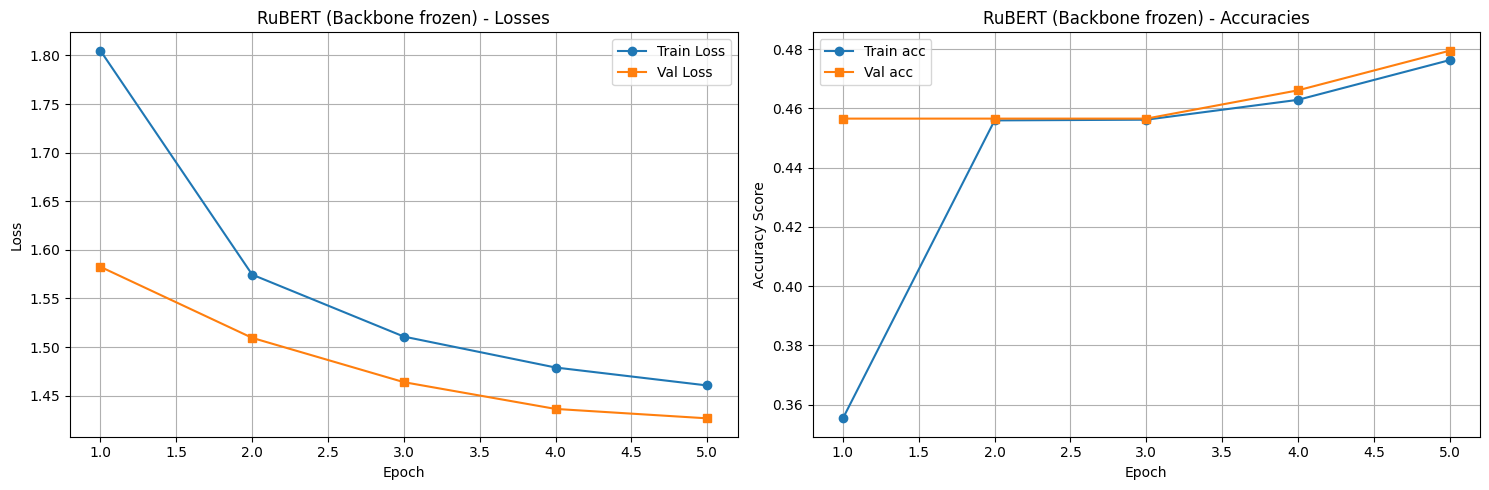

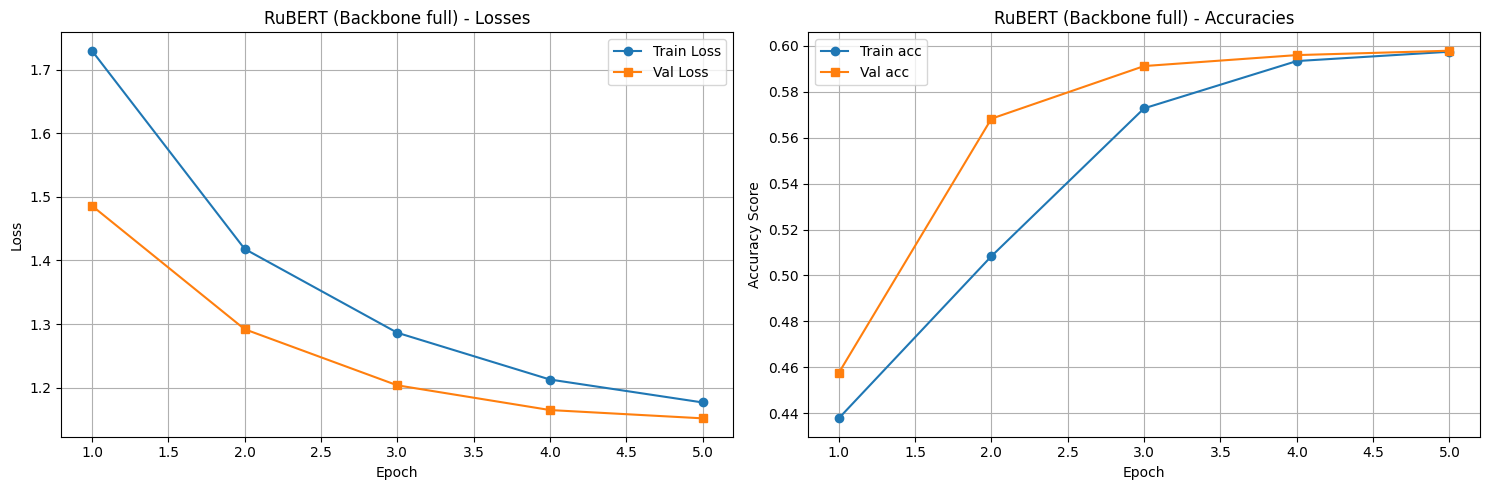

In [40]:
plot_training_history(history_rubert_frozen_fn, 'RuBERT (Backbone frozen)')
plot_training_history(history_rubert_full_fn, 'RuBERT (Backbone full)')

In [41]:
print(f'Best Accuracy model_rubert_frozen: {max(history_rubert_frozen_fn['val_acc']):.4f}')
print(f'Best Accuracy model_rubert_full:   {max(history_rubert_full_fn['val_acc']):.4f}')

Best Accuracy model_rubert_frozen: 0.4795
Best Accuracy model_rubert_full:   0.5979


#### Выводы

**Модель RuBERT с замороженным backbone имеет низкий результат точности (близкий к случайной модели), <br>
так как модель обучалась на русскоязычных корпусах, а тексты в исследуемой таблице на английском языке. <br>
Замороженный backbone не адаптируется к специфике математических задач и формулировок, так еще и написанных на ином языке. <br>
Обучение только одного классификатора недостаточно для сложной классификации. <br>
С размороженным backbone (полное обучение) результаты значительно лучше!**

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

#### DataLoaders для mathbert

In [42]:
MODEL_NAME = 'tbs17/MathBert'

# Токенизатор и эмбеддер для mathbert

tokenizer_mathbert, embedder_mathbert = prepare_tokenizer_and_embedder(model_name=MODEL_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [43]:
# BATCH_SIZE = 8 # 16
# EPOCHS = 5 # 5
# LR = 5e-5 # 5e-5
# MAX_LENGTH = 256 # 256
# DROPOUT = 0.3

In [44]:
# Датасеты и даталоадеры
train_dataset_mathbert = MathDataset(train_texts, train_labels, tokenizer_mathbert, max_length=MAX_LENGTH)
val_dataset_mathbert = MathDataset(val_texts, val_labels, tokenizer_mathbert, max_length=MAX_LENGTH)

g = torch.Generator()
g.manual_seed(SEED)

train_dataloader_mathbert = DataLoader(
    train_dataset_mathbert, 
    shuffle=True, 
    batch_size=BATCH_SIZE,
    collate_fn=collate_batch,
    drop_last=True,
    worker_init_fn=seed_worker, 
    generator=g
)

val_dataloader_mathbert = DataLoader(
    val_dataset_mathbert, 
    shuffle=False, 
    batch_size=BATCH_SIZE,
    collate_fn=collate_batch,
    drop_last=False,
    worker_init_fn=seed_worker, 
    generator=g
)


loaders_mathbert = {'train': train_dataloader_mathbert, 'val': val_dataloader_mathbert}

#### Обучение mathbert с заморозкой backbone

In [45]:
model_mathbert_frozen = TransformerClassificationModel(
    backbone_model_name=MODEL_NAME,
    num_classes=num_classes,
    n_heads=N_HEADS,
    dropout=DROPOUT,
    device=device
    ).to(device)

model_mathbert_frozen = freeze_backbone_function(model_mathbert_frozen)

print()
print(f'Backbone requires_grad: {any(p.requires_grad for p in model_mathbert_frozen.backbone.parameters())}')
print(f'Classifier requires_grad: {any(p.requires_grad for p in model_mathbert_frozen.classifier.parameters())}')

optimizer = optim.AdamW(model_mathbert_frozen.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_dataloader_mathbert) * EPOCHS
scheduler_1 = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
    )

# writer_frozen = SummaryWriter(os.path.join(BASE_FOLDER_PATH, MODEL_NAME.format(MODEL_NAME)))

lambda_scheduler = lambda x: SCHEDULER_LAMBDA_PARAM ** x
scheduler_2 = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_scheduler)

criterion = nn.CrossEntropyLoss()

model_mathbert_frozen_fn, history_mathbert_frozen_fn = train_transformer(
    model=model_mathbert_frozen,
    loaders=loaders_mathbert,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_1,
    # writer = writer_frozen,
    num_epochs=EPOCHS
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Backbone requires_grad: False
Classifier requires_grad: True

Epoch 1/5


Training:   0%|          | 0/261 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Train Loss: 1.1784 | Acc: 0.5908
Val   Loss: 1.1360 | Acc: 0.5798
Best!!!

Epoch 5/5


Training:   0%|          | 0/261 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Train Loss: 1.1524 | Acc: 0.5891
Val   Loss: 1.1255 | Acc: 0.5864
Best!!!


#### Обучение mathbert без заморозки backbone

In [46]:
LR = 1e-5

model_mathbert_full = TransformerClassificationModel(
    backbone_model_name=MODEL_NAME,
    num_classes=num_classes,
    n_heads=N_HEADS,
    dropout=DROPOUT,
    device=device
    ).to(device)

print()
print(f'Backbone requires_grad: {any(p.requires_grad for p in model_mathbert_full.backbone.parameters())}')
print(f'Classifier requires_grad: {any(p.requires_grad for p in model_mathbert_full.classifier.parameters())}')

optimizer = optim.AdamW(model_mathbert_full.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_dataloader_mathbert) * EPOCHS
scheduler_1 = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
    )

# writer_full = SummaryWriter(os.path.join(BASE_FOLDER_PATH, MODEL_NAME.format(MODEL_NAME)))

lambda_scheduler = lambda x: SCHEDULER_LAMBDA_PARAM ** x
scheduler_2 = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_scheduler)

criterion = nn.CrossEntropyLoss()

model_mathbert_full_fn, history_mathbert_full_fn = train_transformer(
    model=model_mathbert_full,
    loaders=loaders_mathbert,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_1,
    # writer = writer_full,
    num_epochs=EPOCHS
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Backbone requires_grad: True
Classifier requires_grad: True

Epoch 1/5


Training:   0%|          | 0/261 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Train Loss: 0.8923 | Acc: 0.6959
Val   Loss: 1.0292 | Acc: 0.6160

Epoch 5/5


Training:   0%|          | 0/261 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Train Loss: 0.8288 | Acc: 0.7141
Val   Loss: 1.0347 | Acc: 0.6170
Best!!!


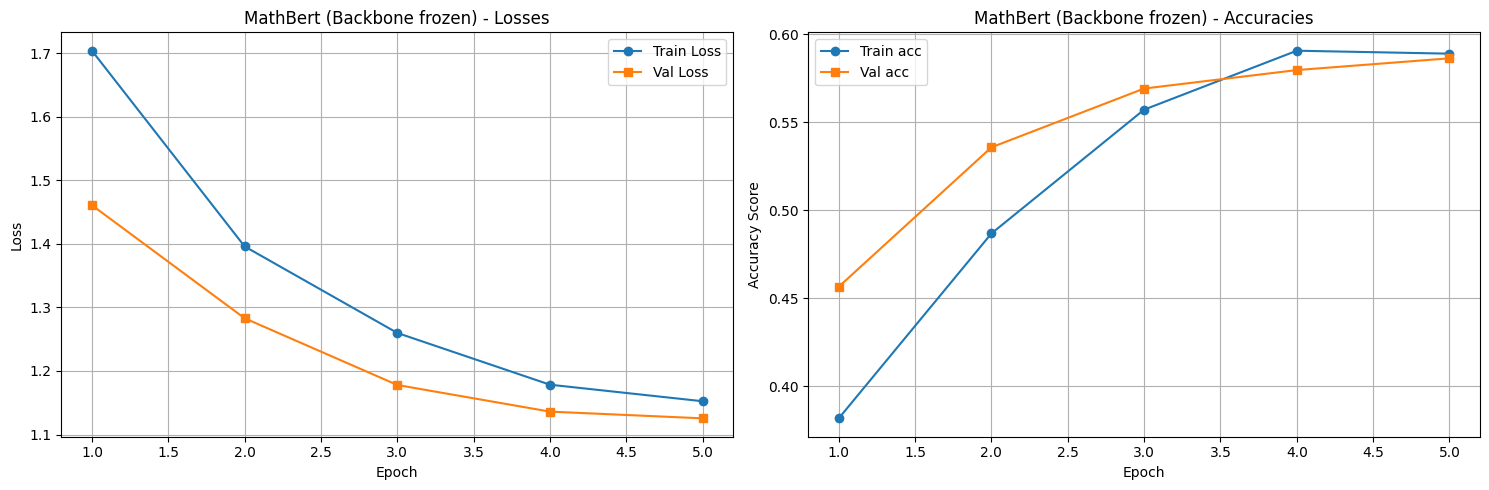

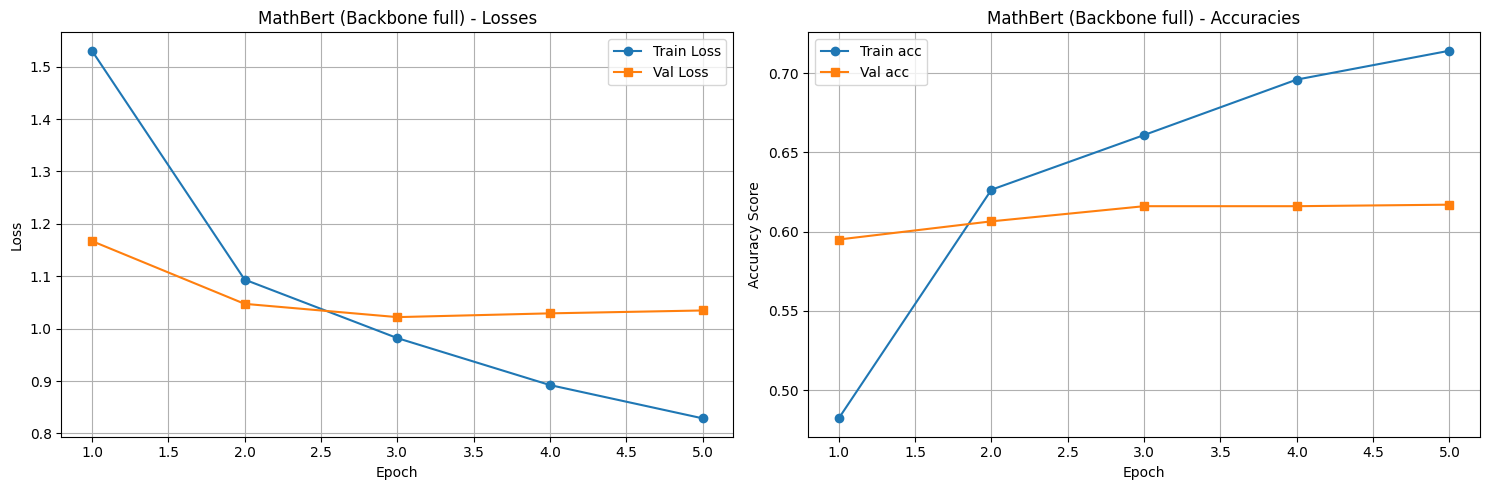

In [47]:
plot_training_history(history_mathbert_frozen_fn, 'MathBert (Backbone frozen)')
plot_training_history(history_mathbert_full_fn, 'MathBert (Backbone full)')

In [48]:
print(f'Best Accuracy model_mathbert_frozen: {max(history_mathbert_frozen_fn['val_acc']):.4f}')
print(f'Best Accuracy model_mathbert_full:   {max(history_mathbert_full_fn['val_acc']):.4f}')

Best Accuracy model_mathbert_frozen: 0.5864
Best Accuracy model_mathbert_full:   0.6170


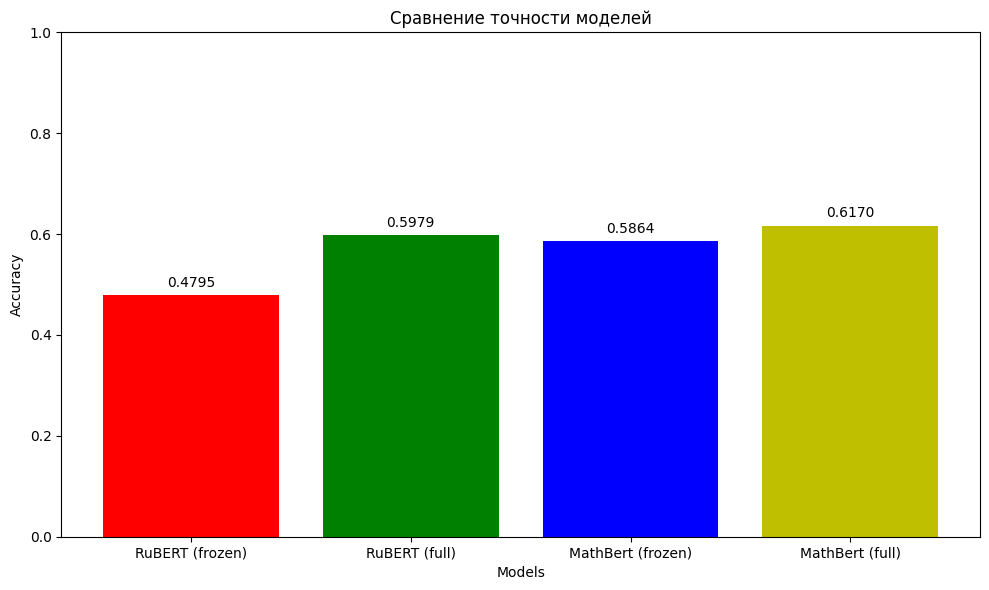

In [49]:
# Bar plot сравнения

models = ['RuBERT (frozen)', 'RuBERT (full)', 
          'MathBert (frozen)', 'MathBert (full)']
accuracies = [max(history['val_acc']) for history in 
              [history_rubert_frozen_fn, history_rubert_full_fn, 
              history_mathbert_frozen_fn, history_mathbert_full_fn]]

colors = list('rgby')

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Сравнение точности моделей')
plt.ylim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

plt.show();

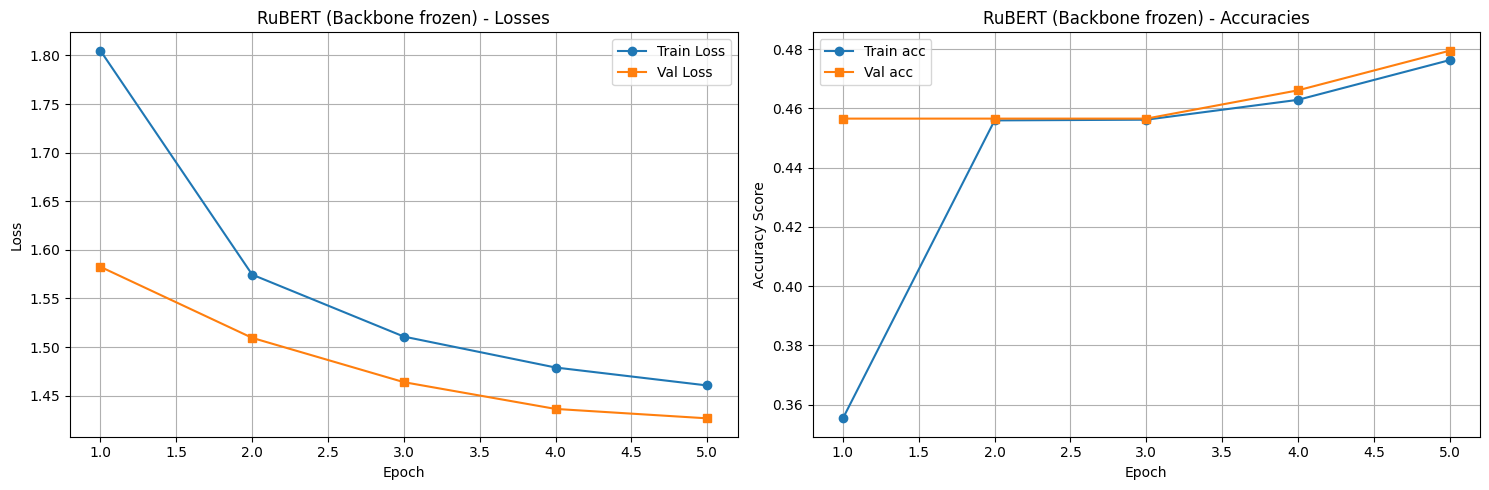

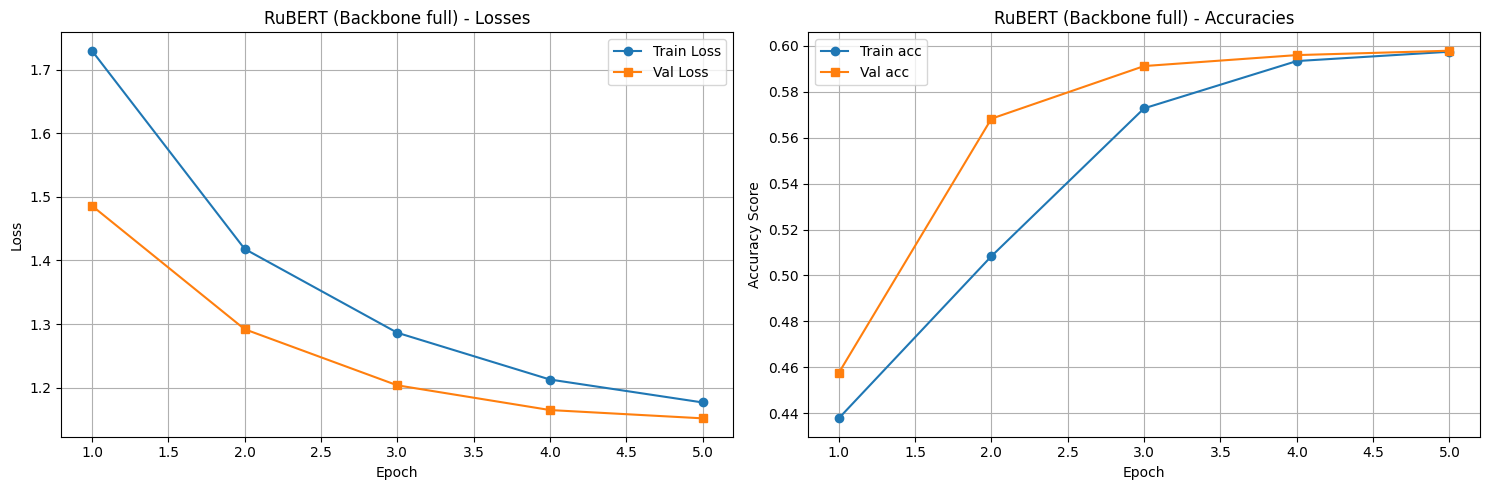

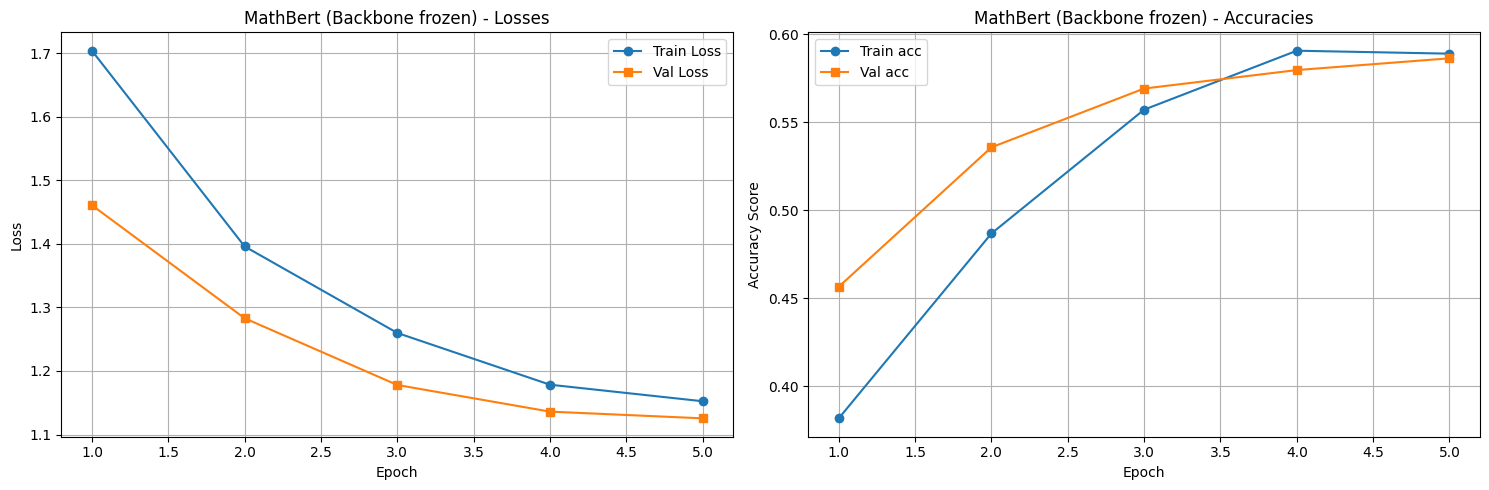

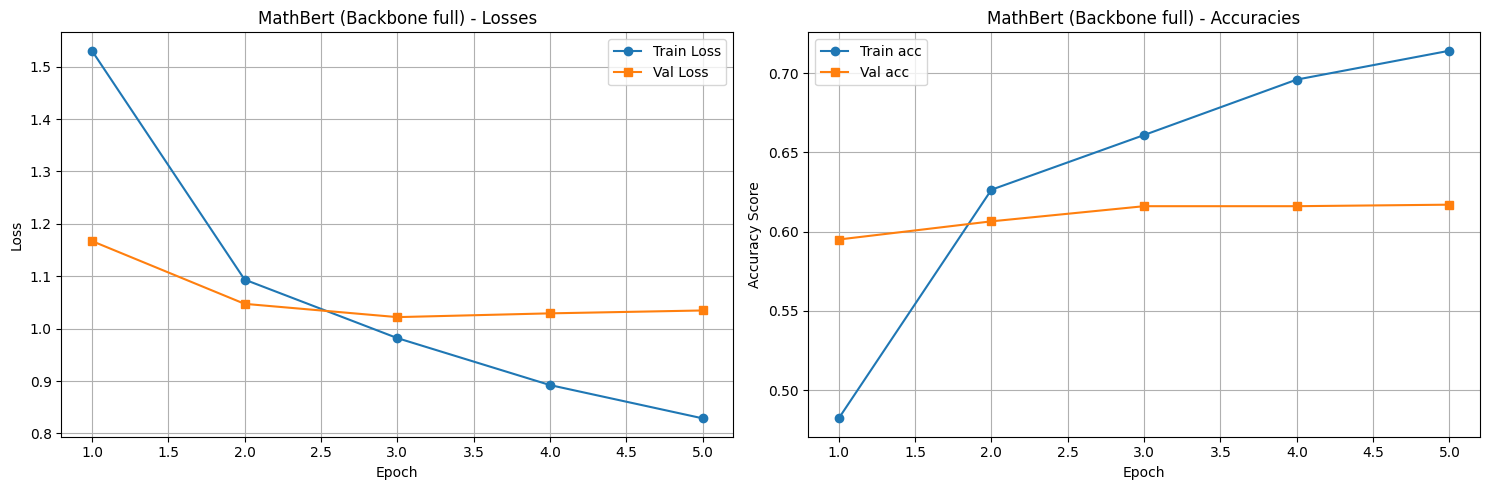

In [50]:
plot_training_history(history_rubert_frozen_fn, 'RuBERT (Backbone frozen)')
plot_training_history(history_rubert_full_fn, 'RuBERT (Backbone full)')
plot_training_history(history_mathbert_frozen_fn, 'MathBert (Backbone frozen)')
plot_training_history(history_mathbert_full_fn, 'MathBert (Backbone full)')

#### Выводы

**Модель MathBert специализацируется на математическом домене (обучен на математических корпусках) и, следовательно, <br>
имеет предобученные эмбеддинги лучшего качества, что помогает модели лучше разделять тексты по классам. <br>
Модели MathBert с заморженным и размороженным backbone имеют скор выше, чем аналогичные модели RuBERT!**

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [51]:
def draw_first_layer_attention_maps(
    attention_head_ids: List[int],
    text: str,
    model: TransformerClassificationModel,
    tokenizer=None,
    figsize_per_head=(8, 6),
    cmap='YlOrRd',
    ):
    """
    Отрисовка карт внимания первого слоя для указанных голов внимания
    """
    device = next(model.parameters()).device
    
    # Токенизация текста
    encoded = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LENGTH,
    )
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)
        
    config = AutoConfig.from_pretrained(model.backbone.name_or_path)
    config.output_attentions = True
    
    # Временная модель для получения attentions
    backbone_temp = AutoModel.from_pretrained(
        model.backbone.name_or_path,
        config=config,
        attn_implementation='eager',
    ).to(device)
    
    # Веса из обученной модели
    backbone_temp.load_state_dict(model.backbone.state_dict())
    backbone_temp.eval()
    
    # Прямой проход для получения attentions
    with torch.no_grad():
        outputs = backbone_temp(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
        )
    
    first_layer_attn = outputs.attentions[0].squeeze(0)  # (num_heads, seq_len, seq_len)
    
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
    
    # Отрисовка карт внимания
    n_heads = len(attention_head_ids)
    ncols = min(n_heads, 3)
    nrows = (n_heads + ncols - 1) // ncols
    
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_head[0] * ncols, figsize_per_head[1] * nrows),
        squeeze=False,
    )
    
    for idx, head_id in enumerate(attention_head_ids):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        
        attn_matrix = first_layer_attn[head_id].cpu().numpy()
        
        display_tokens = [t if len(t) <= 12 else t[:10] + '..' for t in tokens]
        max_show = 64
        if attn_matrix.shape[0] > max_show:
            attn_matrix = attn_matrix[:max_show, :max_show]
            display_tokens = display_tokens[:max_show]
        
        sns.heatmap(
            attn_matrix,
            xticklabels=display_tokens,
            yticklabels=display_tokens,
            cmap=cmap,
            ax=ax,
            cbar=True,
            square=True,
            vmin=0.0,
            vmax=1.0,
        )
        ax.set_title(f'Head {head_id}')
        ax.set_xlabel('Key tokens')
        ax.set_ylabel('Query tokens')
        ax.tick_params(axis='x', rotation=90)
        ax.tick_params(axis='y', rotation=0)
    
    fig.suptitle(
        f'Текст: "{text[:200]}{'…' if len(text) > 200 else ''}"',
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()

    plt.show()
    
    return fig

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [52]:
# Проверим на двух текстах.

sample_texts = val_df['problem_text'].iloc[:2].tolist()
sample_topics = val_df['topic'].iloc[:2].tolist()

In [53]:
model_rubert_untrained = TransformerClassificationModel(
    backbone_model_name='cointegrated/rubert-tiny2',
    num_classes=num_classes,
    n_heads=N_HEADS,
    dropout=DROPOUT,
    device=device
).to(device)

model_mathbert_untrained = TransformerClassificationModel(
    backbone_model_name='tbs17/MathBert',
    num_classes=num_classes,
    n_heads=N_HEADS,
    dropout=DROPOUT,
    device=device
).to(device)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Текст 1


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


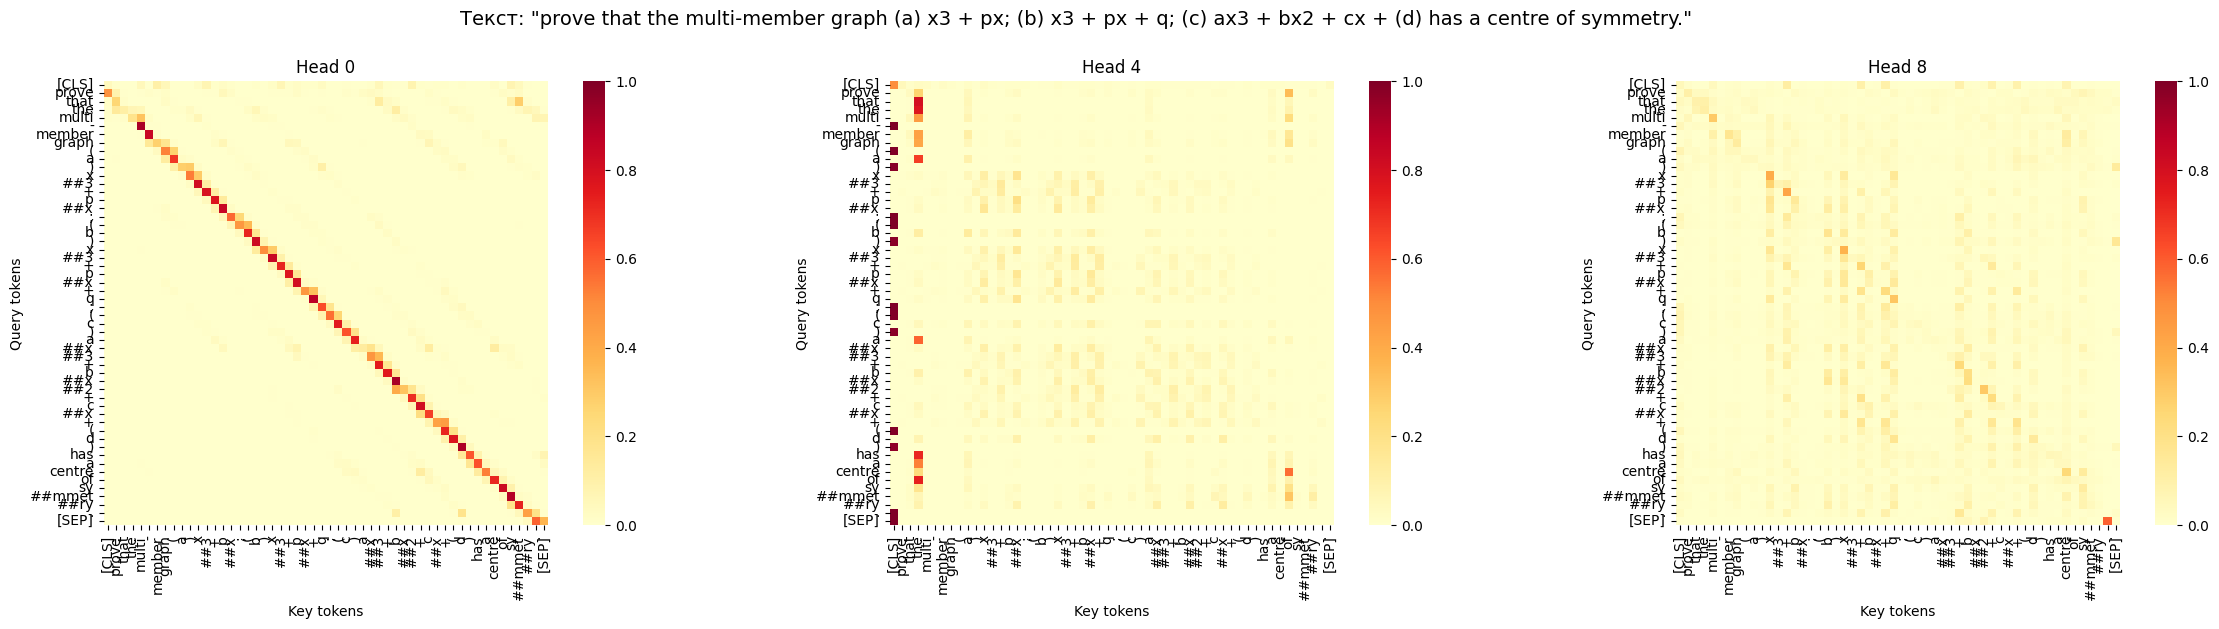


Текст 2


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


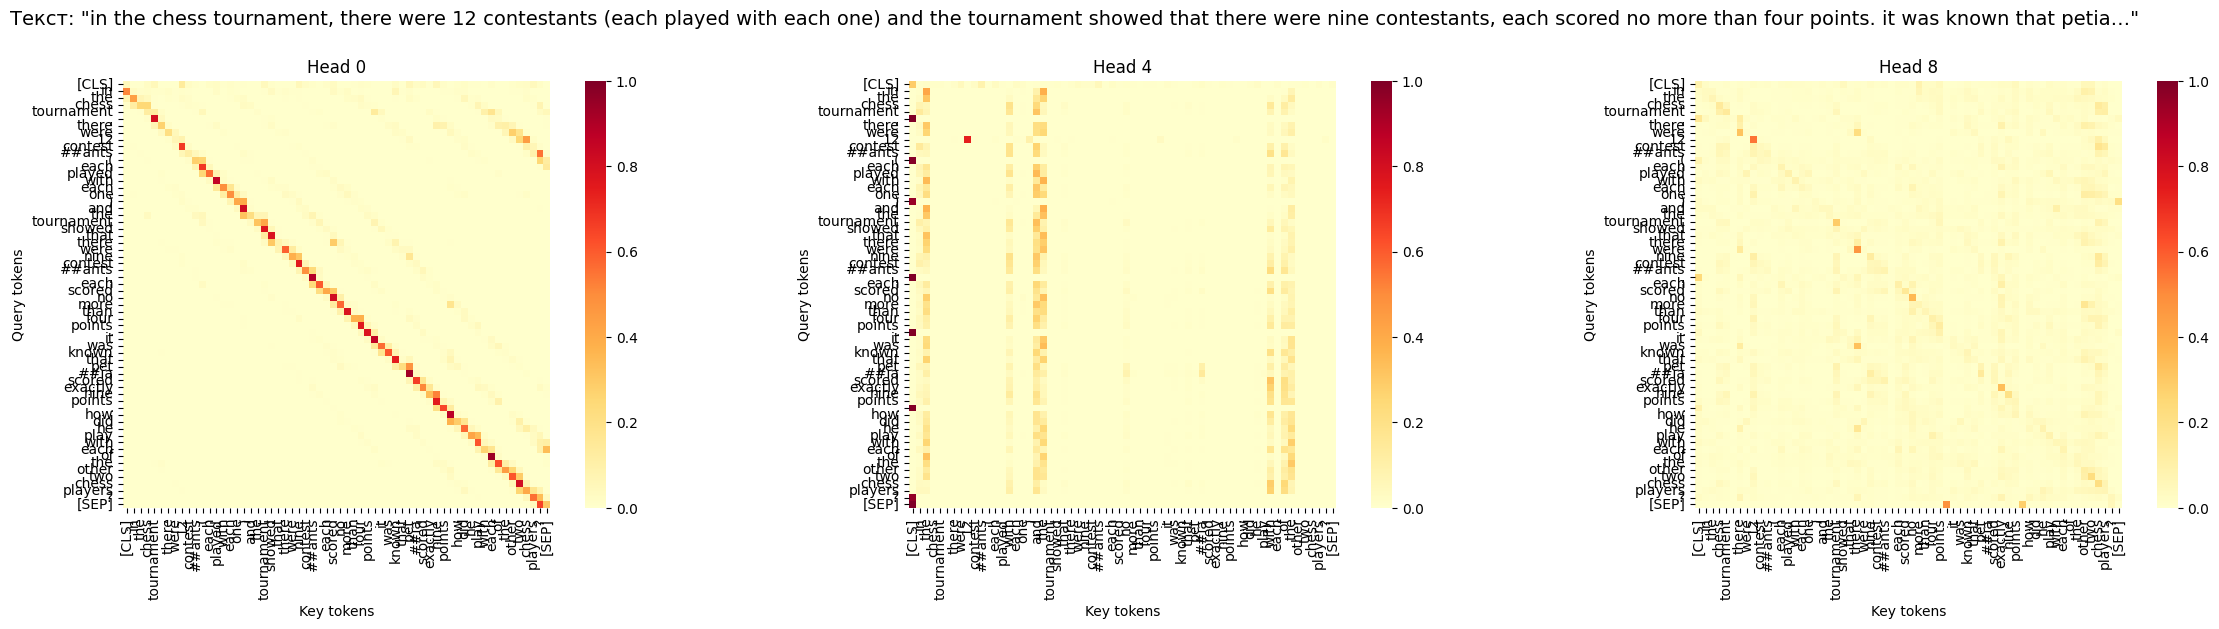

In [54]:
# Карты внимания для RuBERT модели до дообучения

for idx, text in enumerate(sample_texts):
    print(f'\nТекст {idx+1}')
    fig = draw_first_layer_attention_maps(
        attention_head_ids=[0, 4, 8], # номера голов
        text=text,
        model=model_rubert_untrained,
        tokenizer=tokenizer_rubert,
        cmap='YlOrRd',
    )


Текст 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


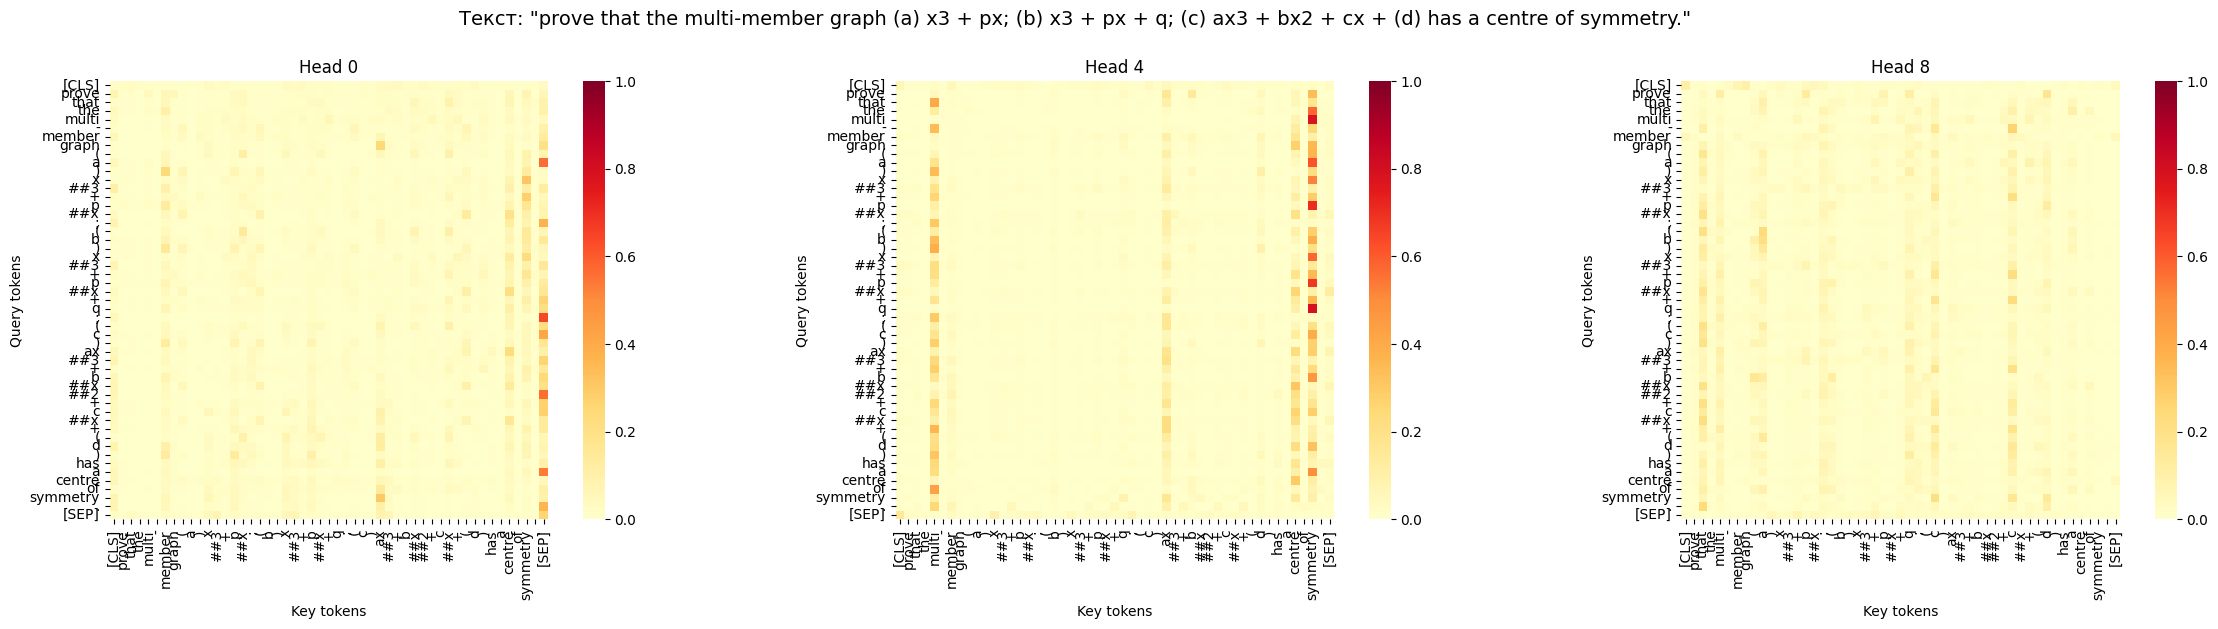


Текст 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


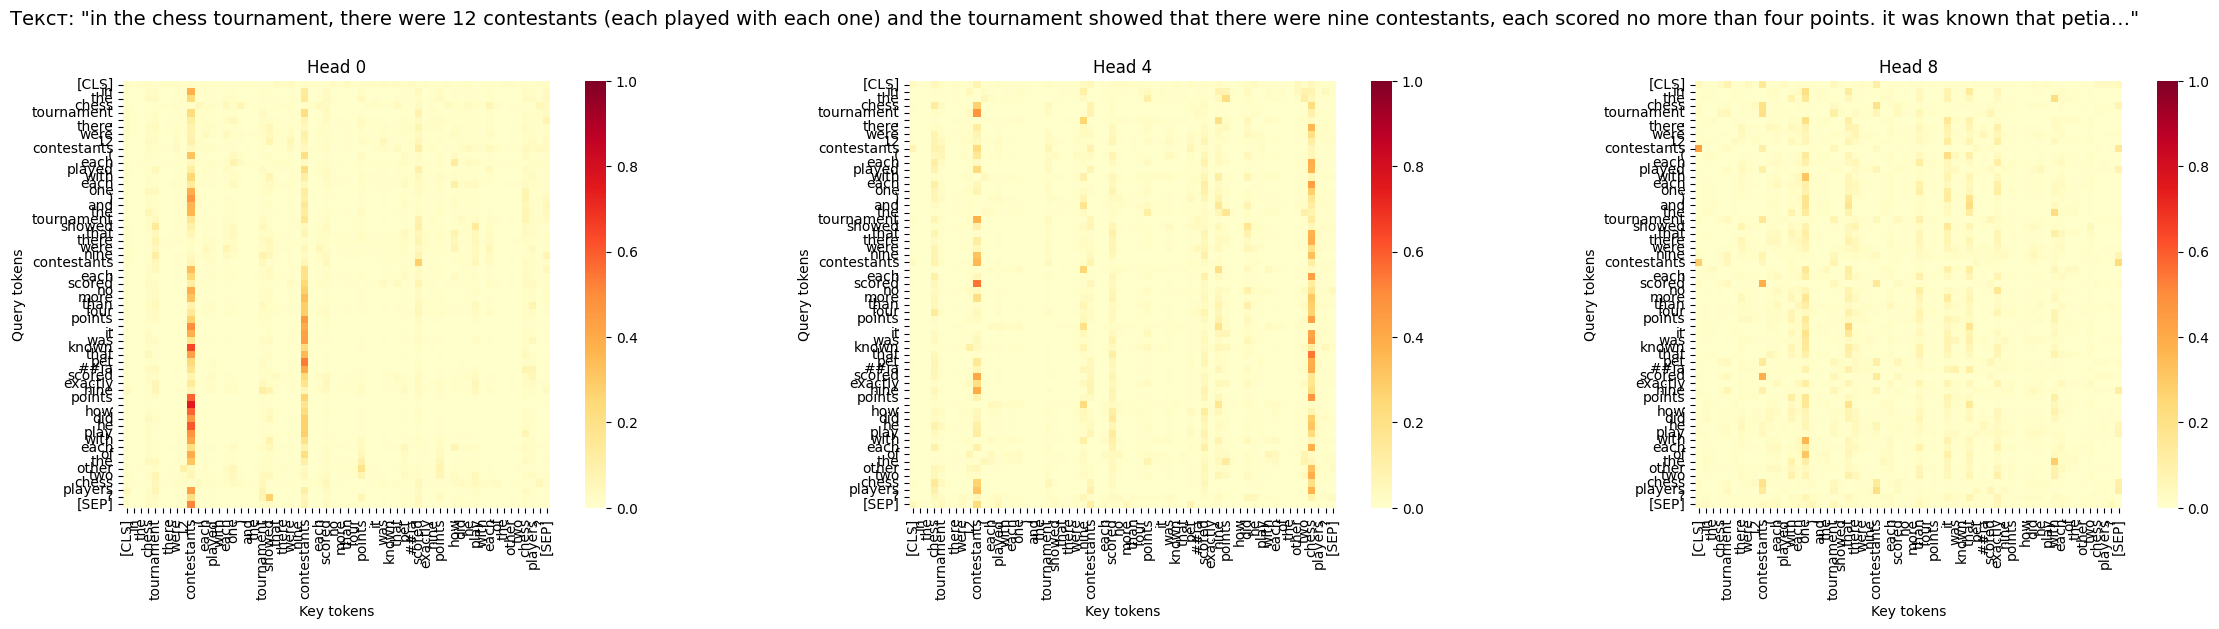

In [55]:
# Карты внимания для MathBert модели до дообучения

for idx, text in enumerate(sample_texts):
    print(f'\nТекст {idx+1}')
    fig = draw_first_layer_attention_maps(
        attention_head_ids=[0, 4, 8],
        text=text,
        model=model_mathbert_untrained,
        tokenizer=tokenizer_mathbert,
        cmap='YlOrRd',
    )

#### Выводы

**В обеих моделях локальное внимание - каждый токен сильно связан с самим собой (диагональ) и с соседними токенами (слева и справа). <br>
Связи с дальними токенами почти отсутствуют.** <br>

**Первые слои трансформеров выучивают базовому синтаксису и грамматике в предложениях и словах, <br>
т.е. модели видят текст как просто текст на английском языке, без математической специфики.**

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?


Текст 1


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


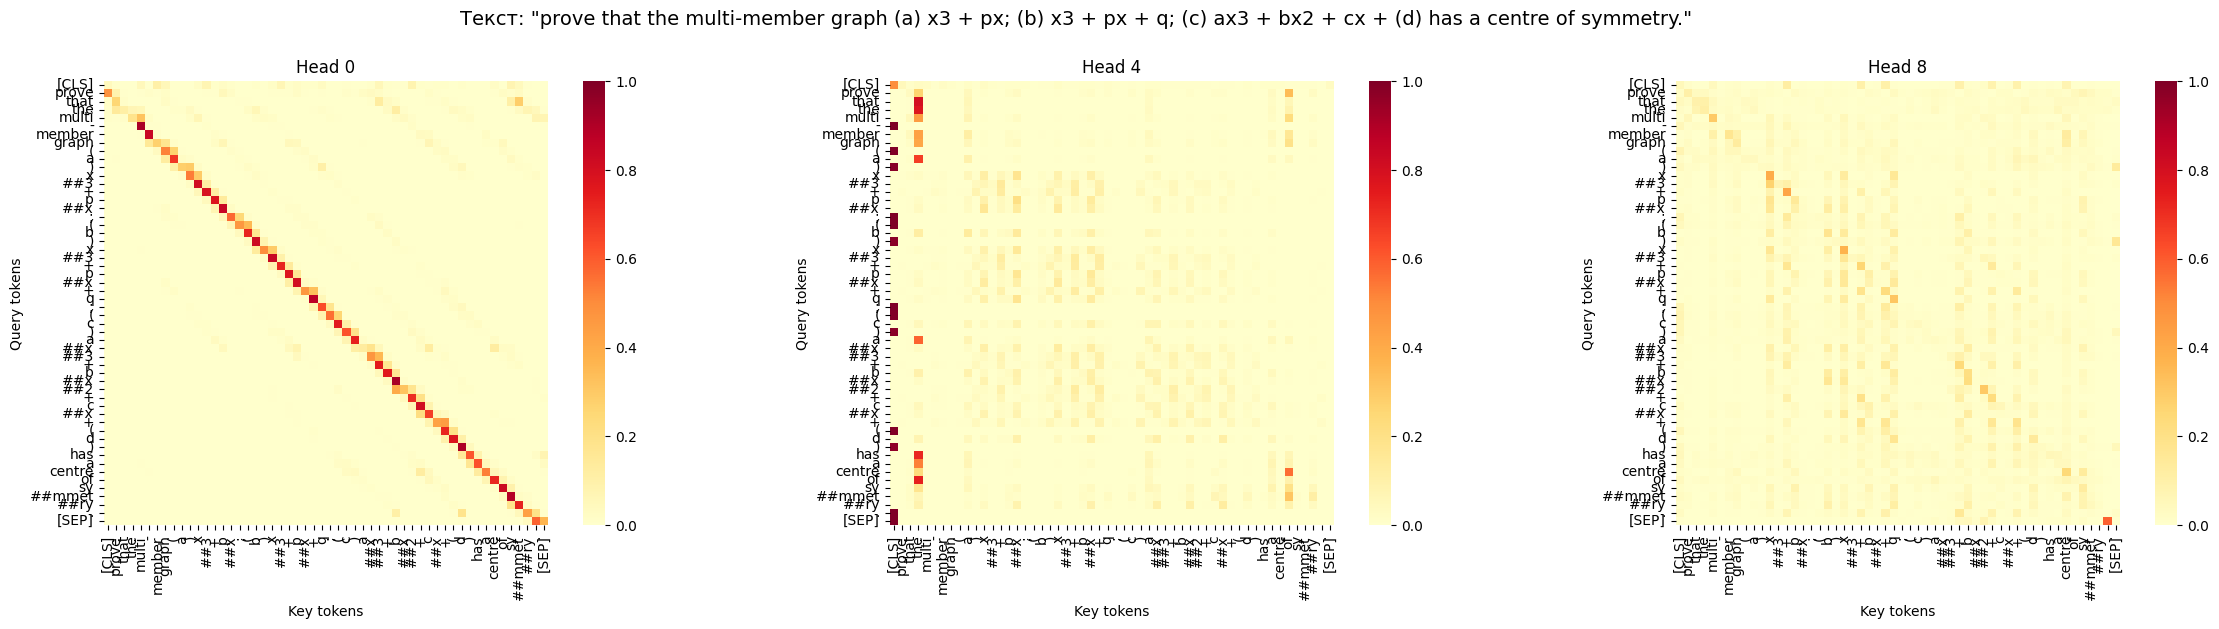


Текст 2


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


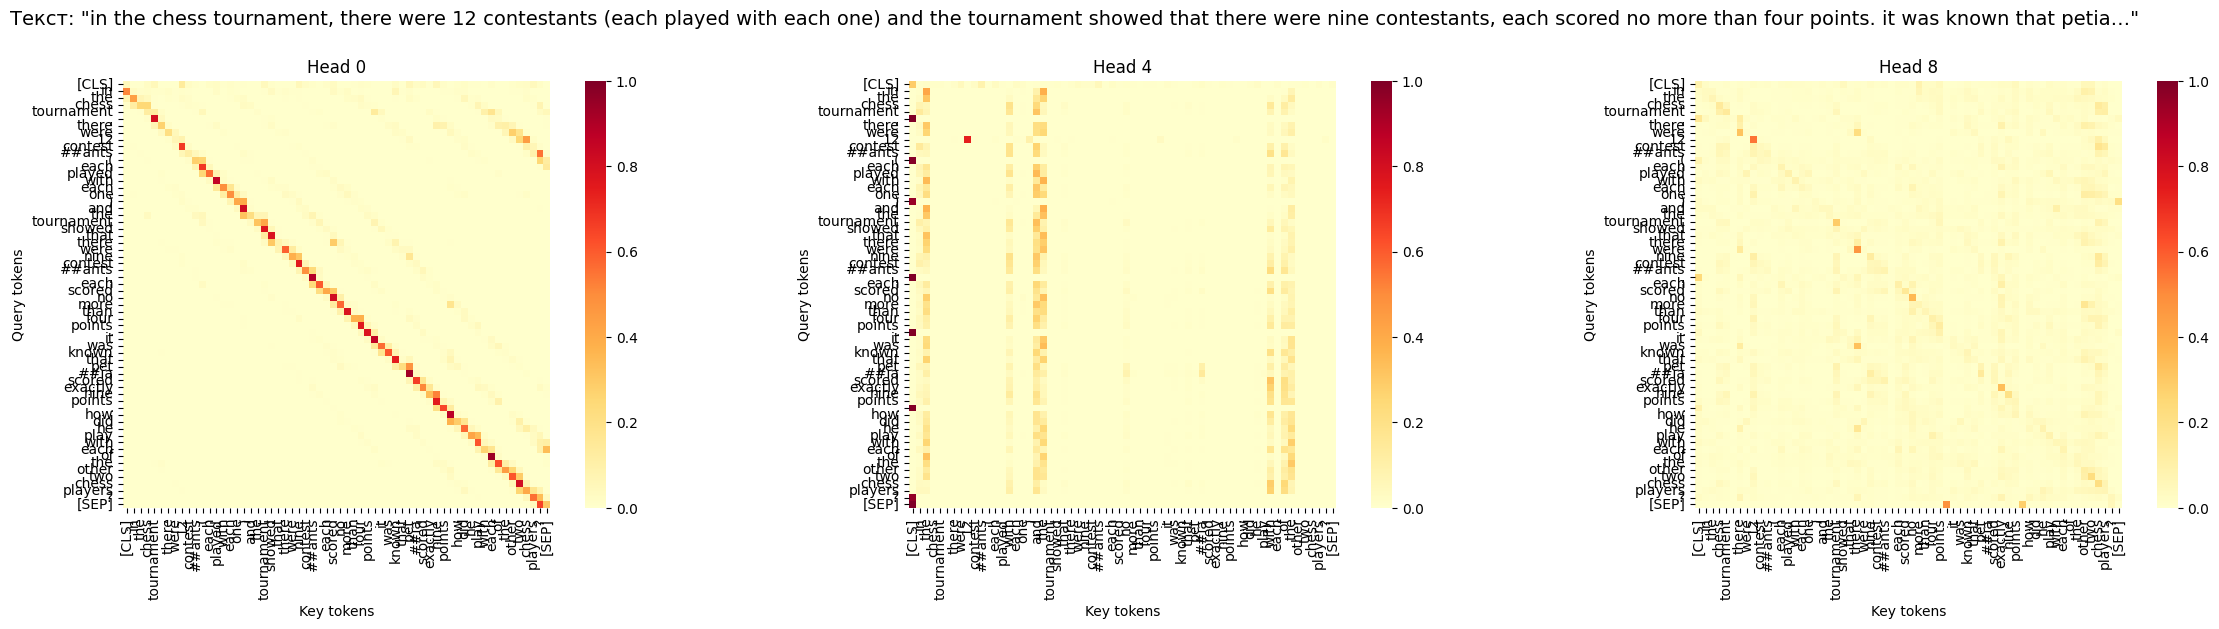

In [56]:
# Карты внимания для RuBERT (Backbone frozen) модели после дообучения

for idx, text in enumerate(sample_texts):
    print(f'\nТекст {idx+1}')
    fig = draw_first_layer_attention_maps(
        attention_head_ids=[0, 4, 8],
        text=text,
        model=model_rubert_frozen_fn,
        tokenizer=tokenizer_rubert,
        cmap='YlOrRd',
    )


Текст 1


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


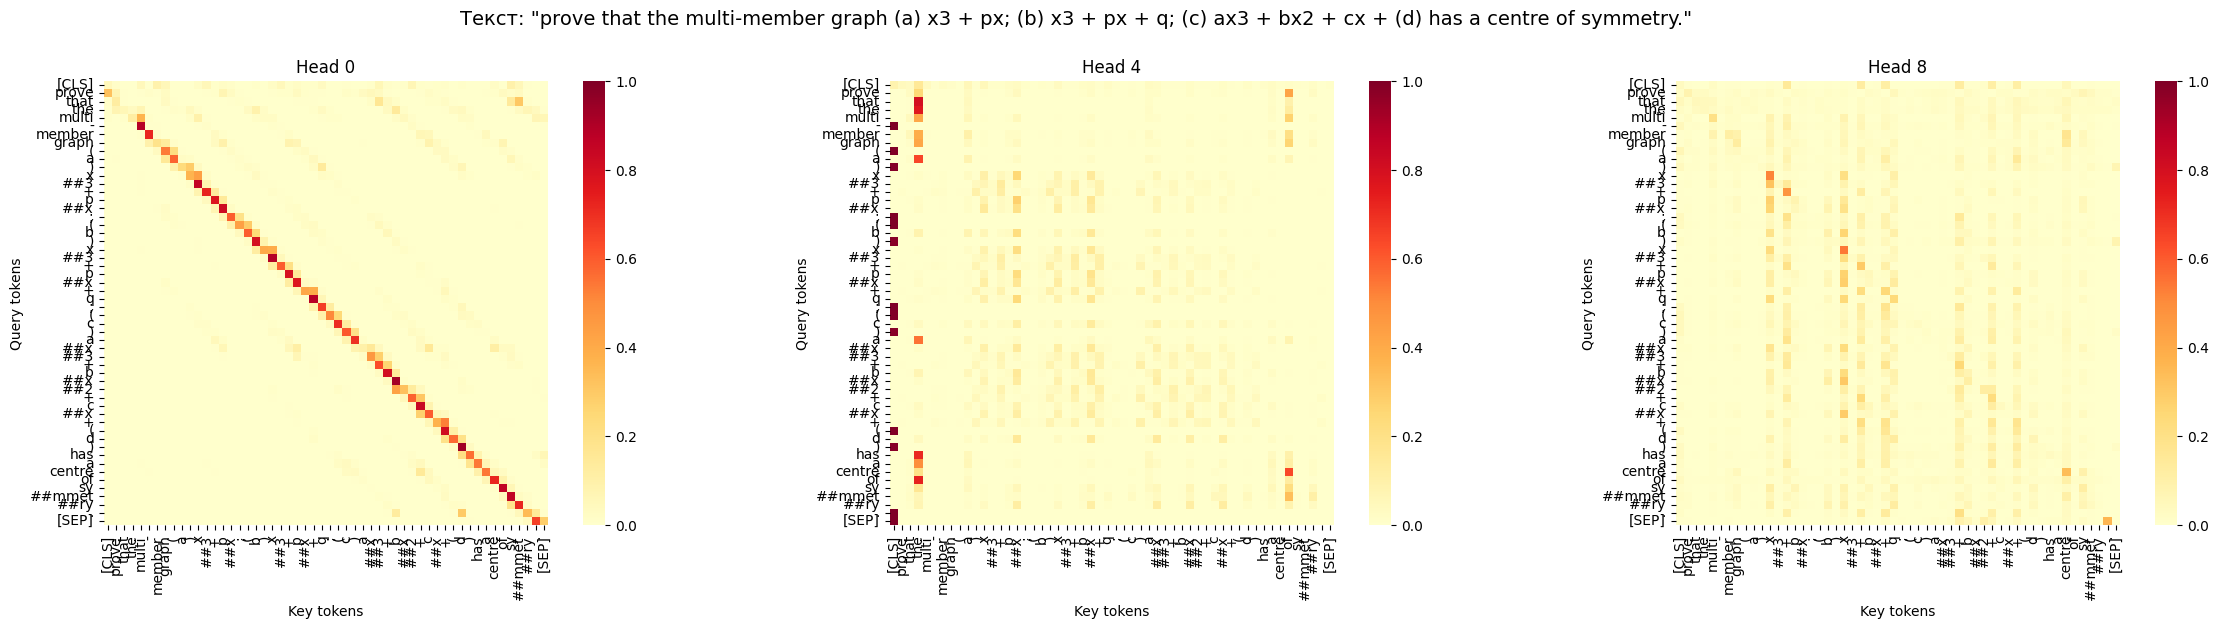


Текст 2


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


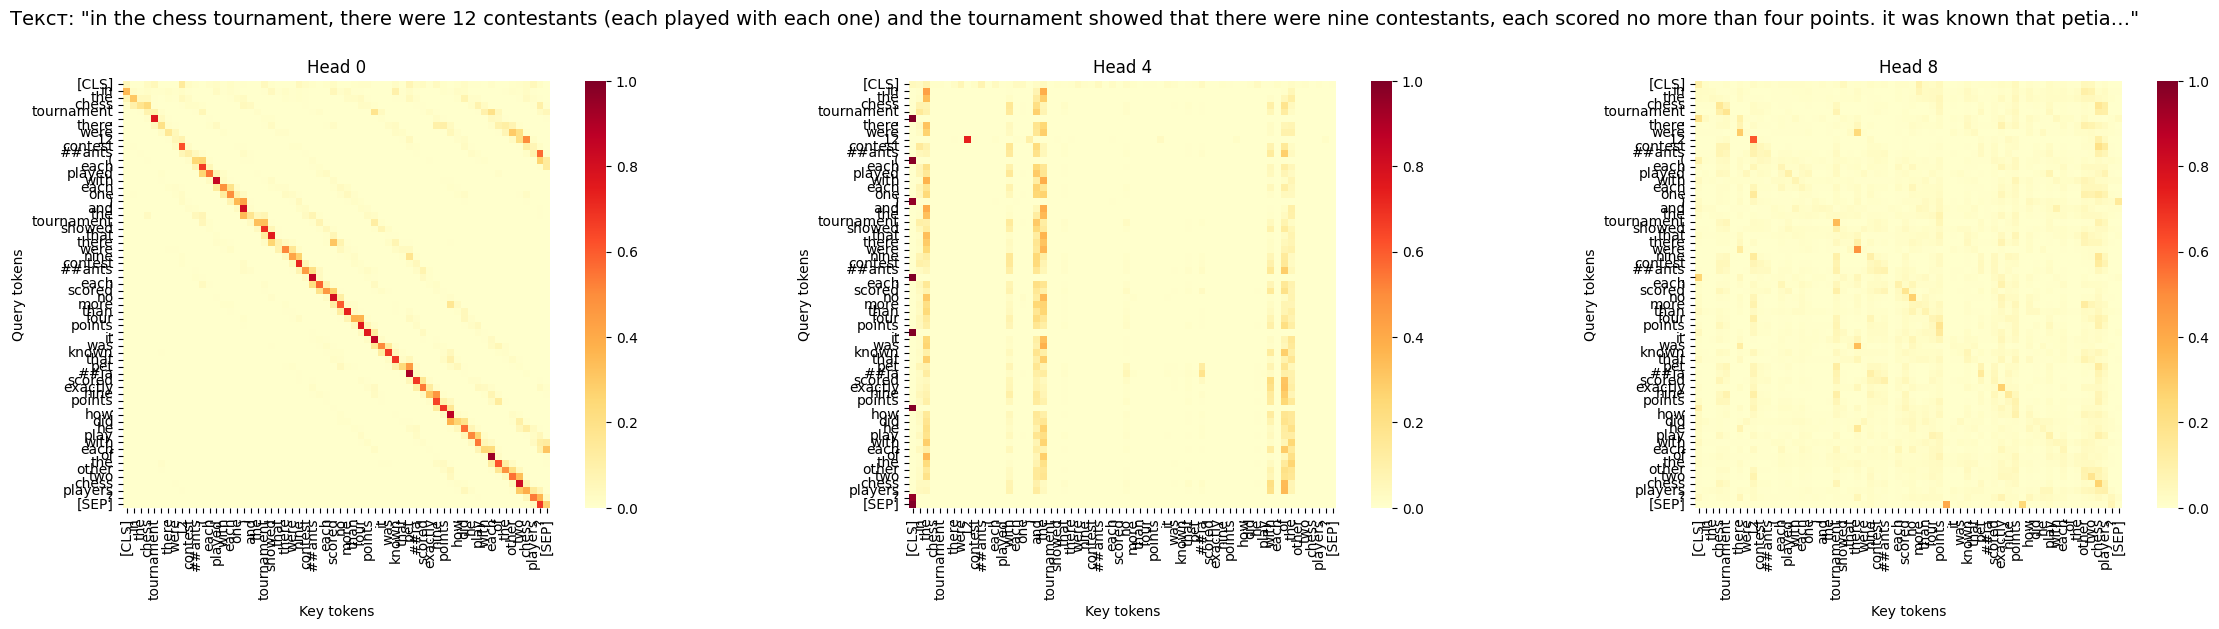

In [57]:
# Карты внимания для RuBERT (Backbone full) модели после дообучения

for idx, text in enumerate(sample_texts):
    print(f'\nТекст {idx+1}')
    fig = draw_first_layer_attention_maps(
        attention_head_ids=[0, 4, 8],
        text=text,
        model=model_rubert_full_fn,
        tokenizer=tokenizer_rubert,
        cmap='YlOrRd',
    )


Текст 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


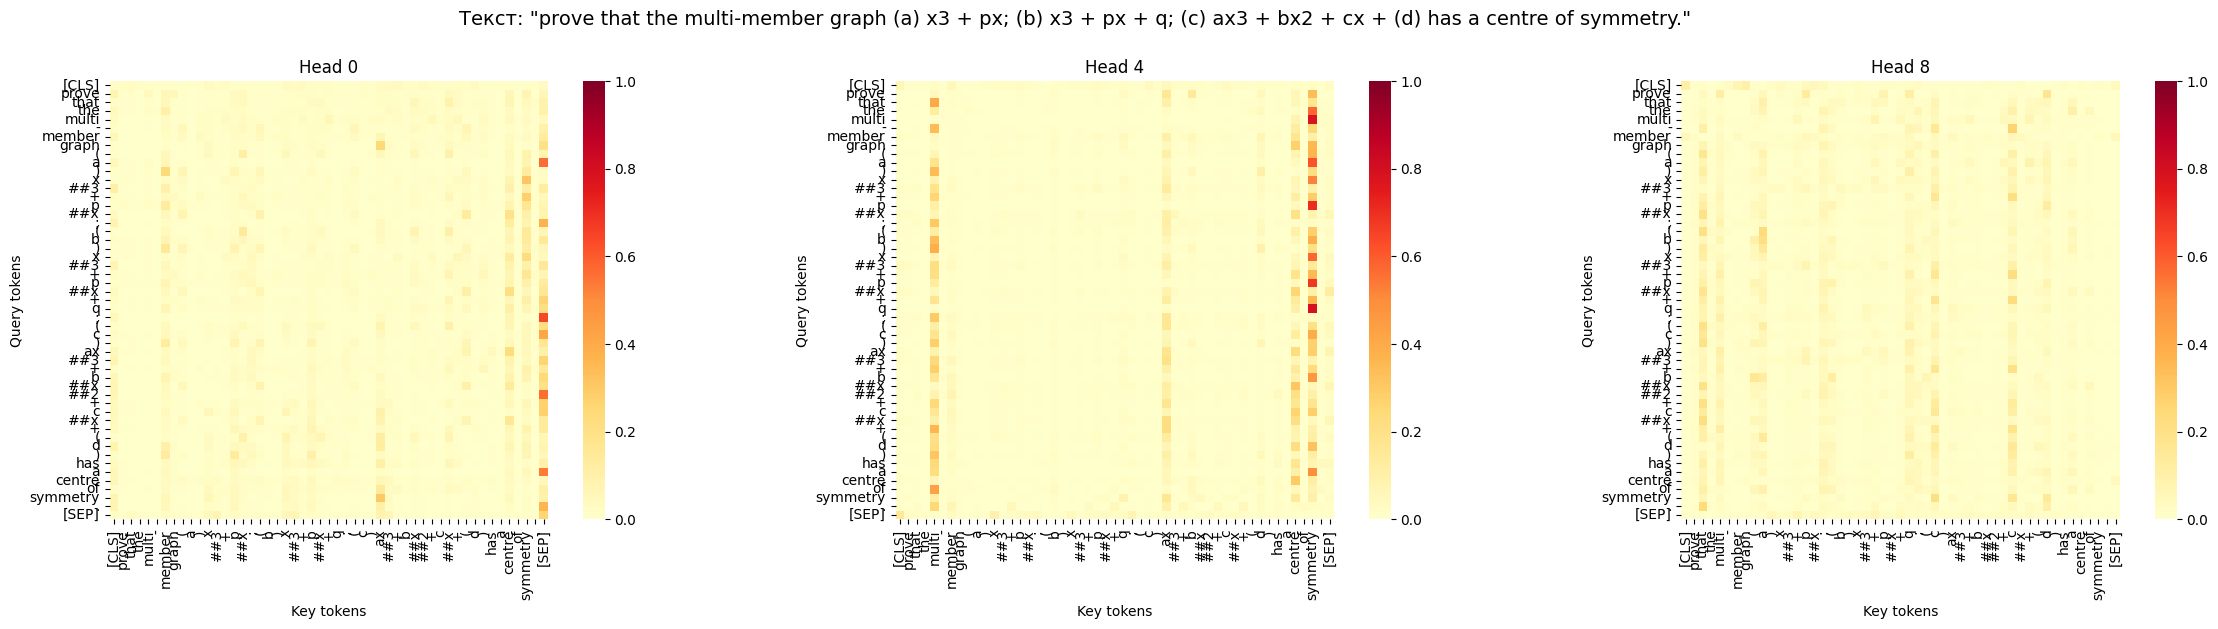


Текст 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


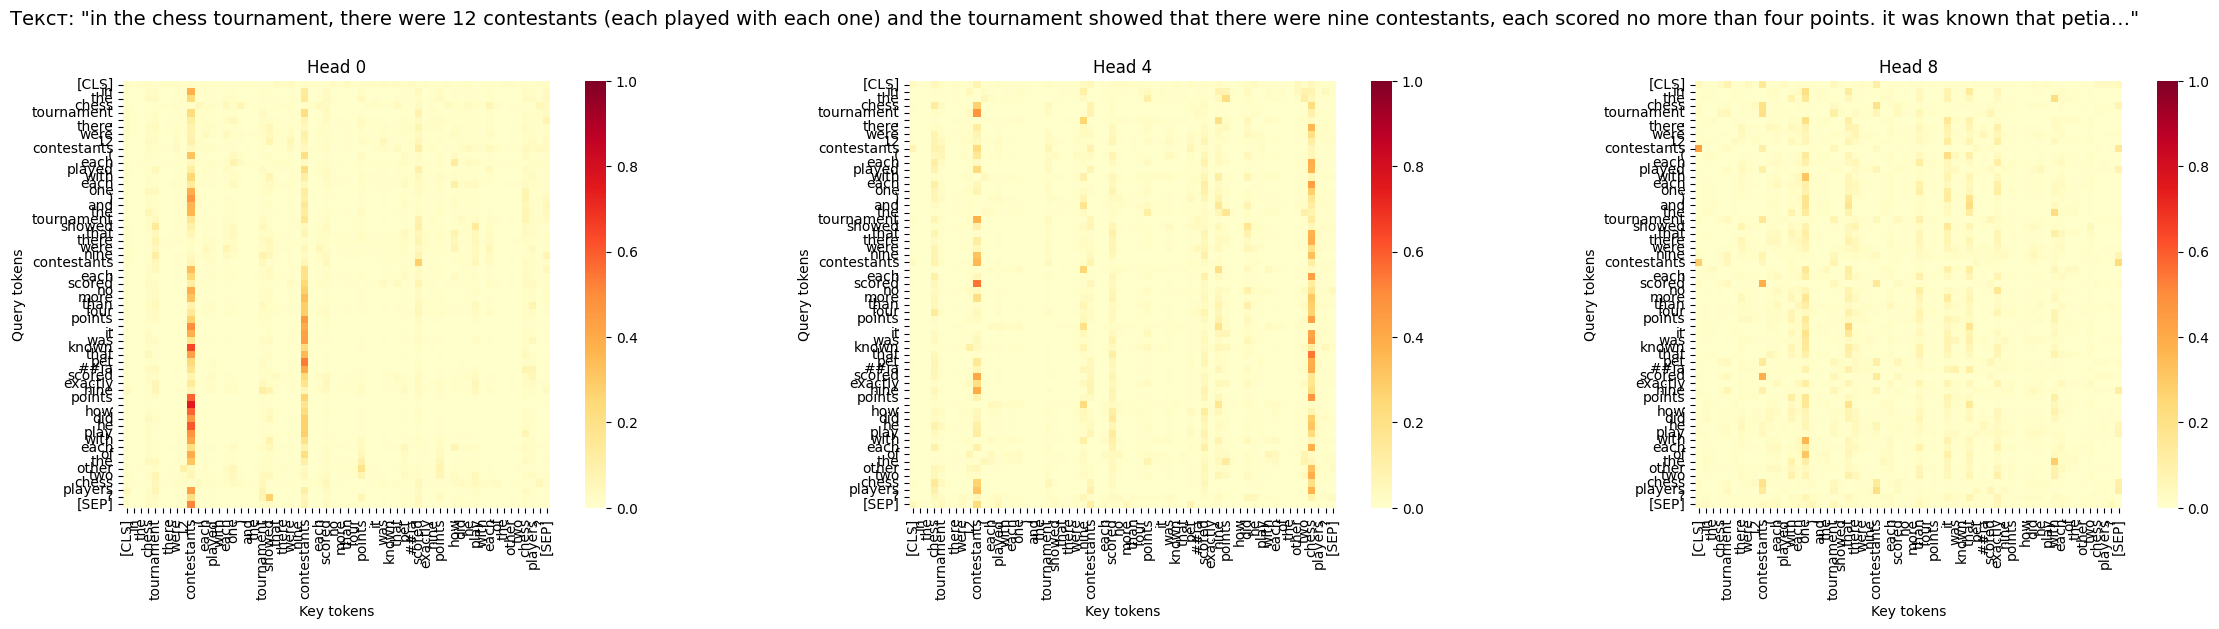

In [58]:
# Карты внимания для MathBert (Backbone frozen) модели после дообучения

for idx, text in enumerate(sample_texts):
    print(f'\nТекст {idx+1}')
    fig = draw_first_layer_attention_maps(
        attention_head_ids=[0, 4, 8],
        text=text,
        model=model_mathbert_frozen_fn,
        tokenizer=tokenizer_mathbert,
        cmap='YlOrRd',
    )


Текст 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


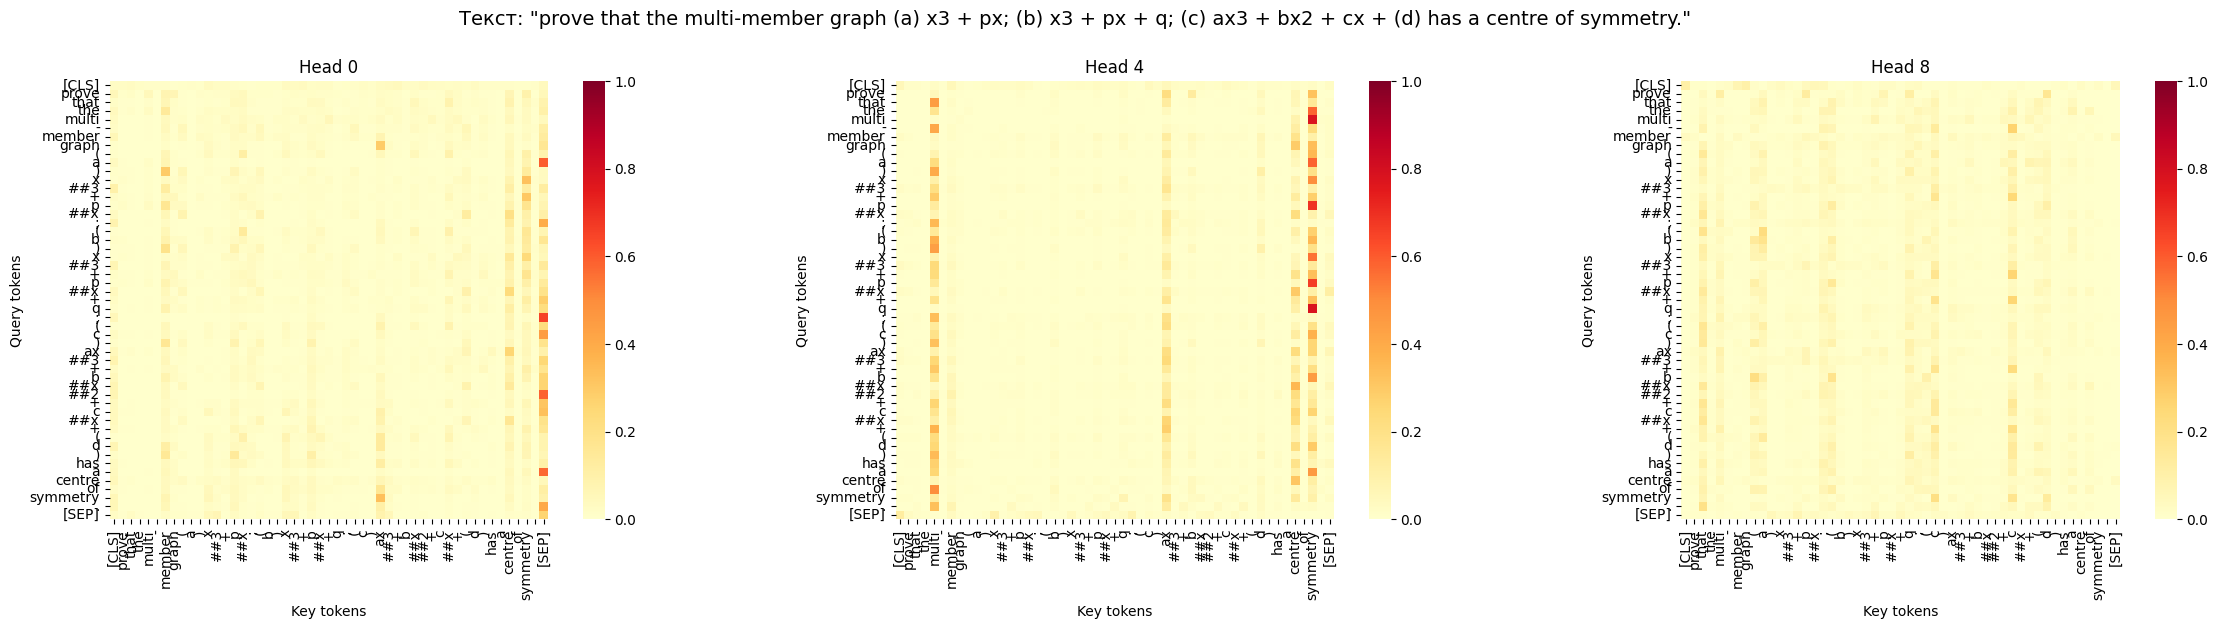


Текст 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


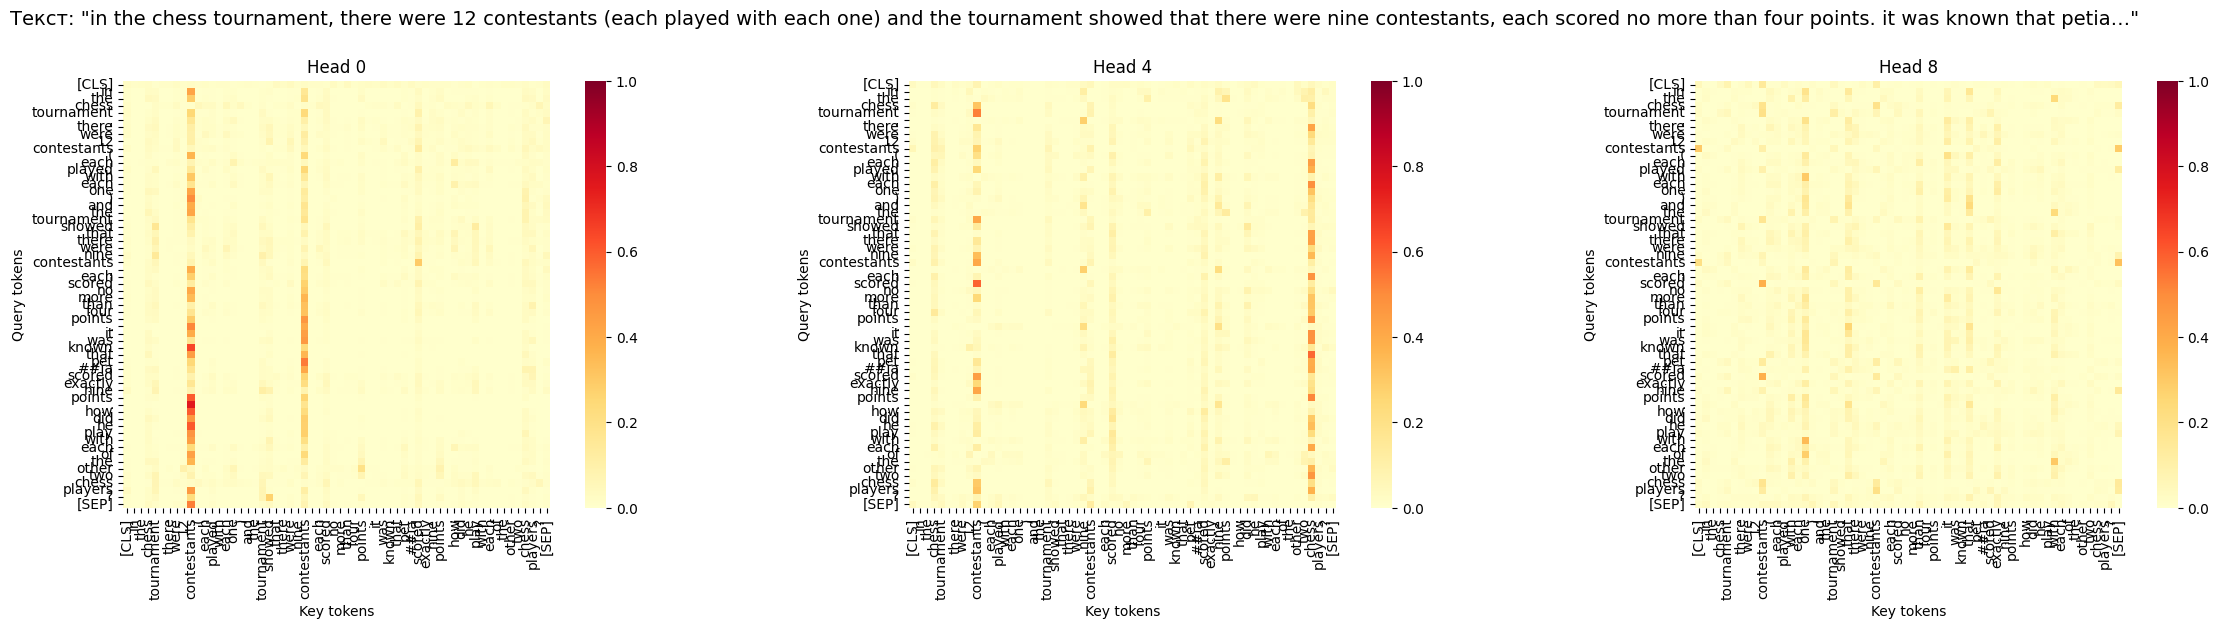

In [59]:
# Карты внимания для RuBERT MathBert (Backbone full) модели после дообучения

for idx, text in enumerate(sample_texts):
    print(f'\nТекст {idx+1}')
    fig = draw_first_layer_attention_maps(
        attention_head_ids=[0, 4, 8],
        text=text,
        model=model_mathbert_full_fn,
        tokenizer=tokenizer_mathbert,
        cmap='YlOrRd',
    )

#### Выводы

**Модели после дообучения начинали выделять ключевые слова, термины, формулировки, <br>
присущие конретным темам. Они являются маркерами тем и помогают разделять текст по тематике. <br>
Модели научилась фокусироваться на тематически значимых словах и конструкциях.** <br><br>

**Различия между frozen и full моделями:** <br>

Frozen backbone не обучается под конретную задачу (слабые изменения внимания), только классификатор адаптируется. <br>
У MathBert изначально backbone обучен на похожей тематике, что и анализируеммый текст, поэтому результаты изначально высокие. <br>

Full модели имеют скор выше - backbone переобучается под задачу. <br>
У MathBert с размороженным backbone прироста сильного не прозошло, так как изначально backbone обучен математических текстах.